# Meyaar — Road Topology Errors with XGBoost

**Goal:** keep Topo4Vec only for synthetic error injection, then replace Geo2Vec + MLP with explicit topology features + XGBoost.

Pipeline:

`Riyadh Roads → Topo4Vec Error Injection → Topology Features → XGBoost → Clean / Overshoot / Undershoot`

This is a **PoC baseline**. The same synthetic labels are reused so the comparison with the previous Topo4Vec/Geo2Vec experiment is easier.

## 1. Upload the files to Colab
Upload these three files in the Colab sidebar:

- `Topo4Vec-peer-review (1).zip`
- `riyadh_roads_clean.geojson`
- `riyadh_connectors_clean.geojson`

Then run the notebook from top to bottom.

In [ ]:
!pip -q install geopandas networkx shapely scikit-learn xgboost matplotlib osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 1.8 MB/s eta 0:00:00


In [ ]:
import os
import ast
import json
import random
import zipfile
from collections import Counter

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt

from shapely.geometry import LineString, Point
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Ready')

Ready


## 2. Paths

In [ ]:
TOPO_ZIP = "/content/Topo4Vec-peer-review.zip"
ROADS_FILE = "/content/riyadh_roads_clean.geojson"
CONNECTORS_FILE = "/content/riyadh_connectors_clean.geojson"
EXTRACT_DIR = "/content/topo4vec_project"

for p in [TOPO_ZIP, ROADS_FILE, CONNECTORS_FILE]:
    print(p, '->', os.path.exists(p))

/content/Topo4Vec-peer-review.zip -> True
/content/riyadh_roads_clean.geojson -> True
/content/riyadh_connectors_clean.geojson -> True


## 3. Extract Topo4Vec and import the original simulation function

In [ ]:
os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(TOPO_ZIP, 'r') as z:
    z.extractall(EXTRACT_DIR)

# Find the folder that contains TopoVec.py automatically
topovec_root = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'TopoVec.py' in files:
        topovec_root = root
        break

if topovec_root is None:
    raise FileNotFoundError('Could not find TopoVec.py after extracting the ZIP')

import sys
if topovec_root not in sys.path:
    sys.path.append(topovec_root)

from TopoVec import apply_stochastic_errors

print('Topo4Vec root:', topovec_root)
print('Simulation imported successfully')

Topo4Vec root: /content/topo4vec_project/Topo4Vec-peer-review
Simulation imported successfully


## 4. Load Riyadh roads and connectors

In [ ]:
roads = gpd.read_file(ROADS_FILE)
connectors = gpd.read_file(CONNECTORS_FILE)

print('Roads:', roads.shape)
print('Connectors:', connectors.shape)
print('Road CRS:', roads.crs)
print('Connector CRS:', connectors.crs)
print('Road geometry types:')
print(roads.geom_type.value_counts())

/usr/local/lib/python3.13/dist-packages/geopandas/io/file.py:576: UserWarning: Could not parse column 'level_rules' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


Roads: (291878, 20)
Connectors: (249934, 4)
Road CRS: EPSG:4326
Connector CRS: EPSG:4326
Road geometry types:
LineString         291866
MultiLineString        12
Name: count, dtype: int64


## 5. Parse road endpoint connectors

In [ ]:
def parse_connectors(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            return ast.literal_eval(value)
        except Exception:
            try:
                return json.loads(value)
            except Exception:
                return []
    return []

def get_road_endpoints(value):
    conns = parse_connectors(value)
    start_id, end_id = None, None
    for c in conns:
        if c.get('at') == 0.0:
            start_id = c.get('connector_id')
        elif c.get('at') == 1.0:
            end_id = c.get('connector_id')
    return start_id, end_id

roads[['start_connector', 'end_connector']] = roads['connectors'].apply(
    lambda x: pd.Series(get_road_endpoints(x))
)

# Keep LineStrings only for this PoC
roads_valid = roads[roads.geom_type == 'LineString'].dropna(
    subset=['start_connector', 'end_connector']
).copy()

connector_ids = set(connectors['id'])
roads_valid = roads_valid[
    roads_valid['start_connector'].isin(connector_ids) &
    roads_valid['end_connector'].isin(connector_ids)
].copy()

connector_lookup = connectors.set_index('id')['geometry'].to_dict()

print('Valid roads:', len(roads_valid))

Valid roads: 291470


## 6. Build the road graph and select a connected sample
We use the same idea as the previous notebook: start from a highly connected node and collect a connected neighborhood of roads.

In [ ]:
G = nx.MultiDiGraph()

for connector_id, geom in connector_lookup.items():
    G.add_node(connector_id, x=geom.x, y=geom.y)

for idx, row in roads_valid.iterrows():
    G.add_edge(
        row['start_connector'],
        row['end_connector'],
        key=row['id'],
        road_index=idx
    )

degrees = dict(G.degree())
seed_node = max(degrees, key=degrees.get)

selected_edges = []
visited_nodes = set()
queue = [seed_node]

while queue and len(selected_edges) < 1000:
    node = queue.pop(0)
    if node in visited_nodes:
        continue
    visited_nodes.add(node)

    for u, v, key, data in G.edges(node, keys=True, data=True):
        selected_edges.append(data['road_index'])
        if v not in visited_nodes:
            queue.append(v)
        if len(selected_edges) >= 1000:
            break

selected_edges = list(dict.fromkeys(selected_edges))[:1000]
roads_sample = roads_valid.loc[selected_edges].copy().reset_index(drop=True)

print('Seed degree:', degrees[seed_node])
print('Selected roads:', len(roads_sample))

Seed degree: 9
Selected roads: 1000


## 7. Build the sample graph expected by Topo4Vec

In [ ]:
G_sample = nx.MultiDiGraph()
graph_edge_to_id = {}
clean_geometry = []

for local_id, row in roads_sample.iterrows():
    u = row['start_connector']
    v = row['end_connector']

    u_geom = connector_lookup[u]
    v_geom = connector_lookup[v]

    G_sample.add_node(u, x=u_geom.x, y=u_geom.y)
    G_sample.add_node(v, x=v_geom.x, y=v_geom.y)
    G_sample.add_edge(u, v, key=local_id)

    graph_edge_to_id[(u, v, local_id)] = local_id
    clean_geometry.append(row.geometry)

print('Sample nodes:', G_sample.number_of_nodes())
print('Sample edges:', G_sample.number_of_edges())

Sample nodes: 733
Sample edges: 1000


## 8. Inject Overshoot and Undershoot using Topo4Vec
This is the **same synthetic-error idea** used in the previous notebook. We are only changing the learned representation/classifier afterwards.

In [ ]:
random.seed(SEED)
np.random.seed(SEED)

(
    corrupted_geometry,
    corrupted_flags,
    new_corrupted_nodes,
    error_types,
    neighborhood_ids
) = apply_stochastic_errors(
    clean_geometry,
    G_sample,
    graph_edge_to_id,
    error_rate=0.50,
    mu_magnitude=0.4,
    sigma_magnitude=0.3
)

labels = [e if e is not None else 'clean' for e in error_types]

print('Total roads:', len(labels))
print('Corrupted roads:', int(sum(corrupted_flags)))
print('Class distribution:', Counter(labels))

Target corruption count: 500 (rate=0.5). Valid candidates: 943
Corrupted 394 edges after applying neighbour-protection constraints.
Total roads: 1000
Corrupted roads: 394
Class distribution: Counter({'clean': 606, 'undershoot': 213, 'overshoot': 181})


## 9. Create the labeled dataset
For each road, the model sees its **current geometry** (clean or corrupted) plus its known connector IDs. The original clean geometry is kept only for debugging/ground truth and is **not used as an input feature**.

In [ ]:
sim = roads_sample[['id', 'start_connector', 'end_connector']].copy()
sim['edge_id'] = np.arange(len(sim))
sim['clean_geometry'] = clean_geometry
sim['geometry'] = corrupted_geometry
sim['is_corrupted'] = corrupted_flags
sim['label'] = labels

sim_gdf = gpd.GeoDataFrame(sim, geometry='geometry', crs=roads_sample.crs)

print(sim_gdf['label'].value_counts())
sim_gdf.head()

label
clean         606
undershoot    213
overshoot     181
Name: count, dtype: int64


,id,start_connector,end_connector,edge_id,clean_geometry,geometry,is_corrupted,label
0,66c89f2d-d427-4404-82b0-5485f247eb93,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,13b9d8c9-3276-415e-a852-bb6d8fa33fd4,0,"LINESTRING (46.7163824 24.7043667, 46.7161033 ...","LINESTRING (46.71638 24.70437, 46.7161 24.7040...",False,clean
1,2e29da9a-0778-4ca6-aa62-ad6c87b65426,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,3a1f7954-20da-4506-ad54-5edcdd01f62e,1,"LINESTRING (46.7163824 24.7043667, 46.7158888 ...","LINESTRING (46.71655 24.70441, 46.71589 24.704...",True,overshoot
2,ef3337bc-8126-438b-b0f4-71f0c594bd2c,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,70b48d07-21a5-4942-a13e-c391436d58b4,2,"LINESTRING (46.7163824 24.7043667, 46.7158938 ...","LINESTRING (46.71638 24.70437, 46.71589 24.70456)",False,clean
3,17c3e4da-600a-412f-891b-4da2c9c1a542,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,1bedac5a-ce7d-498a-a853-3dbcdd297b14,3,"LINESTRING (46.7163824 24.7043667, 46.7165194 ...","LINESTRING (46.71638 24.70437, 46.71652 24.704...",False,clean
4,68451abb-5d55-41ff-9bbd-0277614605d5,13b9d8c9-3276-415e-a852-bb6d8fa33fd4,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,4,"LINESTRING (46.7158594 24.70354, 46.7160374 24...","LINESTRING (46.71586 24.70354, 46.71604 24.703...",False,clean


## 10. Project to meters
Distances in EPSG:4326 are degrees, so we project Riyadh data to **UTM Zone 38N (EPSG:32638)** before calculating distances and lengths.

In [ ]:
METRIC_CRS = 'EPSG:32638'

sim_metric = sim_gdf.to_crs(METRIC_CRS)
connectors_metric = connectors.to_crs(METRIC_CRS)
connector_lookup_m = connectors_metric.set_index('id')['geometry'].to_dict()

# Node degree is topology information from the sampled road network
degree_undirected = dict(G_sample.to_undirected().degree())

print('Metric CRS:', sim_metric.crs)

Metric CRS: EPSG:32638


## 11. Extract topology features
Main idea: compare each current road endpoint with its expected connector and describe the local road topology numerically.

Features include endpoint gaps, signed endpoint offsets, road length, straightness, number of vertices, and connector degrees.

In [ ]:
def signed_endpoint_offset(geom, connector_pt, side):
    """
    Signed distance (meters) from expected connector to current endpoint.
    Positive tends to indicate extension beyond the connector; negative tends
    to indicate stopping before it, relative to the road's terminal direction.
    """
    coords = list(geom.coords)
    if len(coords) < 2:
        return 0.0

    if side == 'start':
        endpoint = np.array(coords[0], dtype=float)
        inner = np.array(coords[1], dtype=float)
    else:
        endpoint = np.array(coords[-1], dtype=float)
        inner = np.array(coords[-2], dtype=float)

    outward = endpoint - inner
    norm = np.linalg.norm(outward)
    if norm == 0:
        return 0.0
    outward = outward / norm

    conn = np.array([connector_pt.x, connector_pt.y], dtype=float)
    connector_to_endpoint = endpoint - conn
    return float(np.dot(connector_to_endpoint, outward))


def extract_features(row):
    geom = row.geometry
    start_pt = connector_lookup_m[row['start_connector']]
    end_pt = connector_lookup_m[row['end_connector']]

    coords = list(geom.coords)
    geom_start = Point(coords[0])
    geom_end = Point(coords[-1])

    start_gap = geom_start.distance(start_pt)
    end_gap = geom_end.distance(end_pt)

    start_signed = signed_endpoint_offset(geom, start_pt, 'start')
    end_signed = signed_endpoint_offset(geom, end_pt, 'end')

    length = float(geom.length)
    direct = float(geom_start.distance(geom_end))
    straightness = direct / length if length > 0 else 0.0

    start_degree = degree_undirected.get(row['start_connector'], 0)
    end_degree = degree_undirected.get(row['end_connector'], 0)

    return pd.Series({
        'road_length_m': length,
        'straightness': straightness,
        'num_vertices': len(coords),
        'start_gap_m': start_gap,
        'end_gap_m': end_gap,
        'min_gap_m': min(start_gap, end_gap),
        'max_gap_m': max(start_gap, end_gap),
        'start_signed_offset_m': start_signed,
        'end_signed_offset_m': end_signed,
        'max_signed_offset_m': max(start_signed, end_signed),
        'min_signed_offset_m': min(start_signed, end_signed),
        'start_degree': start_degree,
        'end_degree': end_degree,
        'max_degree': max(start_degree, end_degree),
        'min_degree': min(start_degree, end_degree),
    })

features = sim_metric.apply(extract_features, axis=1)
features['label'] = sim_metric['label'].values
features['edge_id'] = sim_metric['edge_id'].values

print(features.shape)
features.head()

(1000, 17)


,road_length_m,straightness,num_vertices,start_gap_m,end_gap_m,min_gap_m,max_gap_m,start_signed_offset_m,end_signed_offset_m,max_signed_offset_m,min_signed_offset_m,start_degree,end_degree,max_degree,min_degree,label,edge_id
0,106.286238,0.995071,3.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,9.0,4.0,9.0,4.0,clean,0
1,177.939955,0.991872,4.0,17.502594,0.0,0.0,17.502594,17.502594,0.0,17.502594,0.0,9.0,3.0,9.0,3.0,overshoot,1
2,53.970123,1.000000,2.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,9.0,3.0,9.0,3.0,clean,2
3,186.807429,0.997380,5.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,9.0,3.0,9.0,3.0,clean,3
4,106.463420,0.993415,5.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,4.0,9.0,9.0,4.0,clean,4


## 12. Quick feature sanity check

In [ ]:
display(features.groupby('label')[
    ['start_gap_m', 'end_gap_m', 'start_signed_offset_m', 'end_signed_offset_m', 'road_length_m']
].mean().round(3))

,start_gap_m,end_gap_m,start_signed_offset_m,end_signed_offset_m,road_length_m
label,,,,,
clean,0.000,0.000,0.000,0.000,118.574
overshoot,14.721,8.639,14.721,8.639,118.300
undershoot,12.261,10.787,-12.261,-10.787,89.683


## 13. Prepare X and y

In [ ]:
CLASS_TO_ID = {
    "clean": 0,
    "overshoot": 1,
    "undershoot": 2
}

ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}

feature_cols = [
    c for c in features.columns
    if c not in ["label", "edge_id"]
]

X = features[feature_cols].copy()
y = features["label"].map(CLASS_TO_ID).astype(int)

# First split: 80% Train, 20% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

# Split Temporary equally:
# 10% Validation, 10% Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain distribution:")
print(y_train.map(ID_TO_CLASS).value_counts())

print("\nValidation distribution:")
print(y_val.map(ID_TO_CLASS).value_counts())

print("\nTest distribution:")
print(y_test.map(ID_TO_CLASS).value_counts())

Train: (800, 15)
Validation: (100, 15)
Test: (100, 15)

Train distribution:
label
clean         485
undershoot    170
overshoot     145
Name: count, dtype: int64

Validation distribution:
label
clean         60
undershoot    22
overshoot     18
Name: count, dtype: int64

Test distribution:
label
clean         61
undershoot    21
overshoot     18
Name: count, dtype: int64


## 14. Train XGBoost
Balanced sample weights reduce the tendency to favor the majority `clean` class.

In [ ]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    random_state=SEED,
    n_jobs=-1
)

model.fit(X_train, y_train, sample_weight=sample_weights)
print('XGBoost trained')

XGBoost trained


## 15. Evaluate

Validation Accuracy: 1.0
Validation Balanced Accuracy: 1.0

Validation Classification Report:

              precision    recall  f1-score   support

       clean     1.0000    1.0000    1.0000        60
   overshoot     1.0000    1.0000    1.0000        18
  undershoot     1.0000    1.0000    1.0000        22

    accuracy                         1.0000       100
   macro avg     1.0000    1.0000    1.0000       100
weighted avg     1.0000    1.0000    1.0000       100



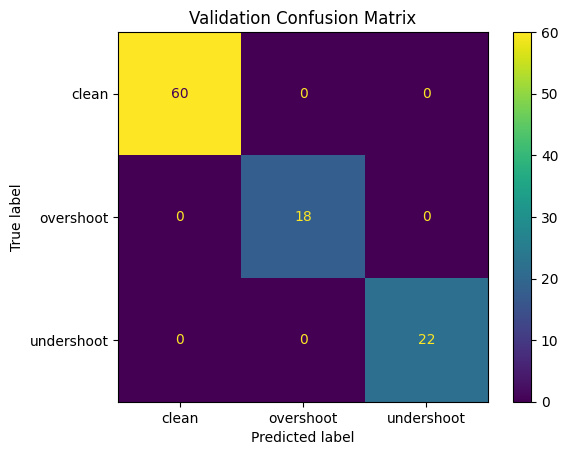

In [ ]:
# Validation predictions
y_val_pred = model.predict(X_val)

print(
    "Validation Accuracy:",
    round(accuracy_score(y_val, y_val_pred), 4)
)

print(
    "Validation Balanced Accuracy:",
    round(balanced_accuracy_score(y_val, y_val_pred), 4)
)

print("\nValidation Classification Report:\n")

print(
    classification_report(
        y_val,
        y_val_pred,
        labels=[0, 1, 2],
        target_names=["clean", "overshoot", "undershoot"],
        digits=4,
        zero_division=0
    )
)

cm_val = confusion_matrix(
    y_val,
    y_val_pred,
    labels=[0, 1, 2]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_val,
    display_labels=["clean", "overshoot", "undershoot"]
)

disp.plot(values_format="d")
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
# Test predictions
y_pred = model.predict(X_test)

print(
    "Test Accuracy:",
    round(accuracy_score(y_test, y_pred), 4)
)

print(
    "Test Balanced Accuracy:",
    round(balanced_accuracy_score(y_test, y_pred), 4)
)

print("\nTest Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        labels=[0, 1, 2],
        target_names=["clean", "overshoot", "undershoot"],
        digits=4,
        zero_division=0
    )
)

Test Accuracy: 0.98
Test Balanced Accuracy: 0.963

Test Classification Report:

              precision    recall  f1-score   support

       clean     0.9683    1.0000    0.9839        61
   overshoot     1.0000    0.8889    0.9412        18
  undershoot     1.0000    1.0000    1.0000        21

    accuracy                         0.9800       100
   macro avg     0.9894    0.9630    0.9750       100
weighted avg     0.9806    0.9800    0.9796       100



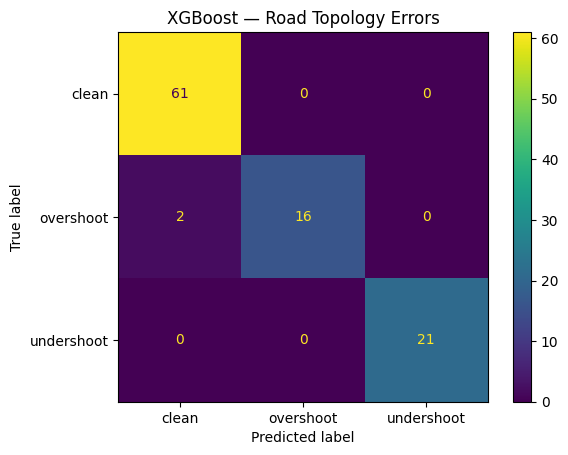

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['clean', 'overshoot', 'undershoot']
)
disp.plot(values_format='d')
plt.title('XGBoost — Road Topology Errors')
plt.show()

## 16. Confusion Matrix

## 17. Feature Importance
This helps explain to the doctor **what the model relied on**.

max_signed_offset_m      0.199528
min_signed_offset_m      0.198651
max_gap_m                0.184818
start_signed_offset_m    0.164868
end_signed_offset_m      0.131432
end_gap_m                0.062741
start_gap_m              0.057922
road_length_m            0.000041
min_gap_m                0.000000
straightness             0.000000
num_vertices             0.000000
start_degree             0.000000
end_degree               0.000000
max_degree               0.000000
min_degree               0.000000
dtype: float32


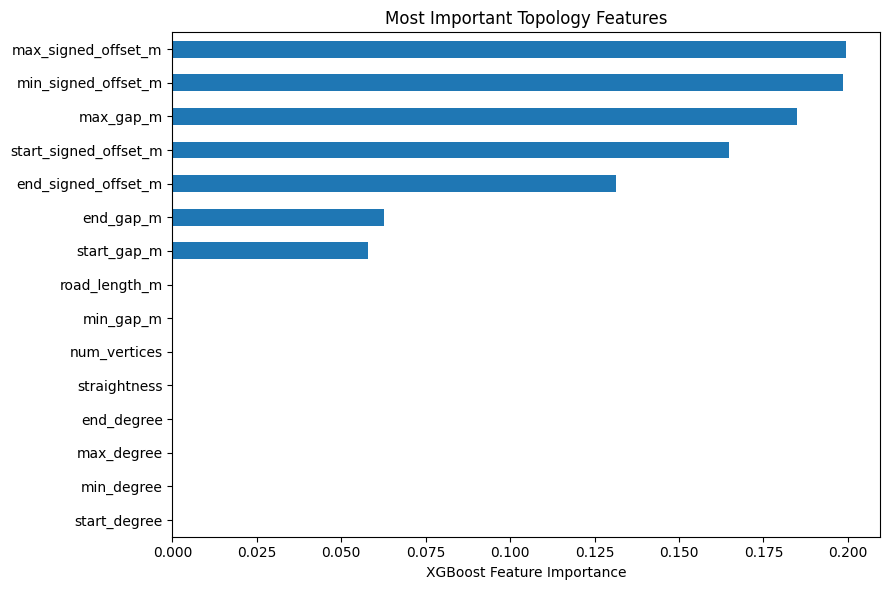

In [ ]:
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(9, 6))
importance.sort_values().plot(kind='barh')
plt.xlabel('XGBoost Feature Importance')
plt.title('Most Important Topology Features')
plt.tight_layout()
plt.show()

## 18. Save predictions

In [ ]:
results = features.loc[X_test.index, ['edge_id', 'label']].copy()
results['predicted_label'] = [ID_TO_CLASS[int(v)] for v in y_pred]
results['correct'] = results['label'] == results['predicted_label']

results.to_csv('/content/meyaar_xgboost_road_results.csv', index=False)
print('Saved: /content/meyaar_xgboost_road_results.csv')
results.head()

Saved: /content/meyaar_xgboost_road_results.csv


,edge_id,label,predicted_label,correct
494,494,clean,clean,True
323,323,clean,clean,True
189,189,clean,clean,True
235,235,clean,clean,True
656,656,clean,clean,True


## How to explain this experiment

> We kept Topo4Vec only as a controlled synthetic-error generator for Overshoot and Undershoot. Instead of Geo2Vec embeddings, we extracted interpretable topology features from each road and its expected connectors, such as endpoint gap, signed offset, road length, and node degree. We then trained XGBoost to classify each road as Clean, Overshoot, or Undershoot and evaluated it using Accuracy, Balanced Accuracy, Precision, Recall, F1, and a Confusion Matrix.

### Important research note
This experiment uses connector positions as explicit reference information. Because the synthetic errors are created by moving road endpoints away from those connectors, some features can be highly informative. Therefore, treat this as an **interpretable ML baseline for the injected-error setting**, not as proof that XGBoost can detect every real-world road topology error without reference topology.

Experiment 2 Features:
['road_length_m', 'straightness', 'num_vertices', 'start_degree', 'end_degree', 'max_degree', 'min_degree']

===== VALIDATION =====
Accuracy: 0.54
Balanced Accuracy: 0.5222
              precision    recall  f1-score   support

       clean     0.7234    0.5667    0.6355        60
   overshoot     0.3600    0.5000    0.4186        18
  undershoot     0.3929    0.5000    0.4400        22

    accuracy                         0.5400       100
   macro avg     0.4921    0.5222    0.4980       100
weighted avg     0.5853    0.5400    0.5535       100


===== TEST =====
Accuracy: 0.53
Balanced Accuracy: 0.4955
              precision    recall  f1-score   support

       clean     0.7143    0.5738    0.6364        61
   overshoot     0.3182    0.3889    0.3500        18
  undershoot     0.3793    0.5238    0.4400        21

    accuracy                         0.5300       100
   macro avg     0.4706    0.4955    0.4755       100
weighted avg     0.5726    0.5300    0

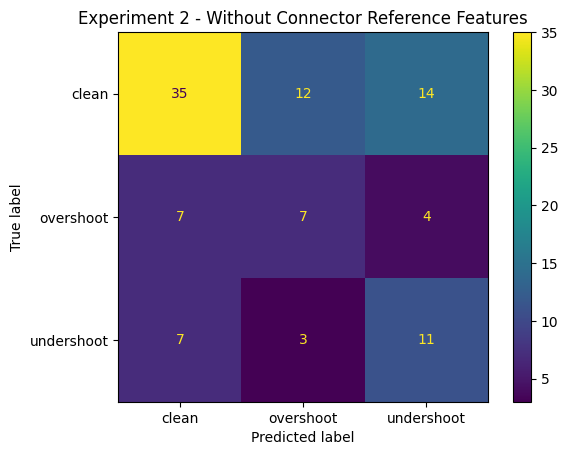

In [ ]:
# Experiment 2: Remove reference-heavy features

reference_heavy_features = [
    "start_gap_m",
    "end_gap_m",
    "min_gap_m",
    "max_gap_m",
    "start_signed_offset_m",
    "end_signed_offset_m",
    "max_signed_offset_m",
    "min_signed_offset_m"
]

experiment2_features = [
    c for c in feature_cols
    if c not in reference_heavy_features
]

print("Experiment 2 Features:")
print(experiment2_features)

X2 = features[experiment2_features].copy()
y2 = features["label"].map(CLASS_TO_ID).astype(int)

# 80% Train, 10% Validation, 10% Test
X2_train, X2_temp, y2_train, y2_temp = train_test_split(
    X2,
    y2,
    test_size=0.20,
    random_state=SEED,
    stratify=y2
)

X2_val, X2_test, y2_val, y2_test = train_test_split(
    X2_temp,
    y2_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y2_temp
)

# Balanced weights
sample_weights2 = compute_sample_weight(
    class_weight="balanced",
    y=y2_train
)

model2 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1
)

model2.fit(
    X2_train,
    y2_train,
    sample_weight=sample_weights2
)

# Validation
y2_val_pred = model2.predict(X2_val)

print("\n===== VALIDATION =====")
print(
    "Accuracy:",
    round(accuracy_score(y2_val, y2_val_pred), 4)
)
print(
    "Balanced Accuracy:",
    round(balanced_accuracy_score(y2_val, y2_val_pred), 4)
)

print(
    classification_report(
        y2_val,
        y2_val_pred,
        labels=[0, 1, 2],
        target_names=["clean", "overshoot", "undershoot"],
        digits=4,
        zero_division=0
    )
)

# Test
y2_test_pred = model2.predict(X2_test)

print("\n===== TEST =====")
print(
    "Accuracy:",
    round(accuracy_score(y2_test, y2_test_pred), 4)
)
print(
    "Balanced Accuracy:",
    round(balanced_accuracy_score(y2_test, y2_test_pred), 4)
)

print(
    classification_report(
        y2_test,
        y2_test_pred,
        labels=[0, 1, 2],
        target_names=["clean", "overshoot", "undershoot"],
        digits=4,
        zero_division=0
    )
)

# Confusion Matrix
cm2 = confusion_matrix(
    y2_test,
    y2_test_pred,
    labels=[0, 1, 2]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=["clean", "overshoot", "undershoot"]
)

disp.plot(values_format="d")
plt.title("Experiment 2 - Without Connector Reference Features")
plt.show()

Experiment 3 Features:
['road_length_m', 'straightness', 'num_vertices', 'start_degree', 'end_degree', 'max_degree', 'min_degree', 'start_nearby_roads', 'end_nearby_roads', 'start_nearest_road_dist', 'end_nearest_road_dist', 'start_nearest_endpoint_dist', 'end_nearest_endpoint_dist', 'start_dangling', 'end_dangling']

===== VALIDATION =====
Accuracy: 0.91
Balanced Accuracy: 0.8401
              precision    recall  f1-score   support

       clean     1.0000    1.0000    1.0000        60
   overshoot     0.8462    0.6111    0.7097        18
  undershoot     0.7407    0.9091    0.8163        22

    accuracy                         0.9100       100
   macro avg     0.8623    0.8401    0.8420       100
weighted avg     0.9153    0.9100    0.9073       100


===== TEST =====
Accuracy: 0.92
Balanced Accuracy: 0.8728
              precision    recall  f1-score   support

       clean     1.0000    0.9836    0.9917        61
   overshoot     0.8235    0.7778    0.8000        18
  undershoot 

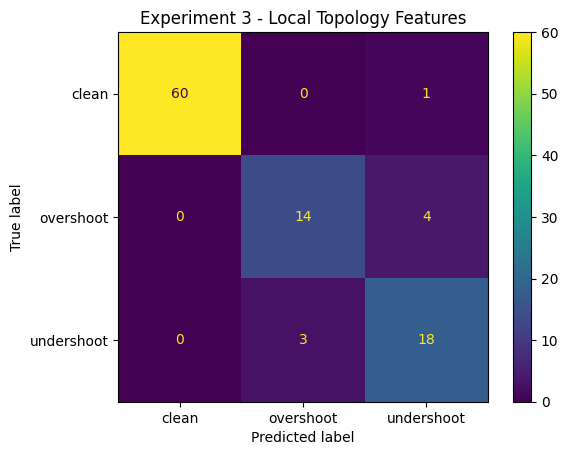

In [ ]:
# Experiment 3: Local Topology Features

from shapely.strtree import STRtree
from shapely.geometry import Point

# نستخدم geometries الحالية بعد حقن الأخطاء
road_geoms = list(sim_metric.geometry)

# Spatial index للطرق
tree = STRtree(road_geoms)

def endpoint_points(geom):
    coords = list(geom.coords)
    return Point(coords[0]), Point(coords[-1])

def local_topology_features(row_idx, geom):
    start_pt, end_pt = endpoint_points(geom)

    # ابحث عن الطرق القريبة من كل endpoint
    search_radius = 20  # meters

    start_candidates_idx = tree.query(start_pt.buffer(search_radius))
    end_candidates_idx = tree.query(end_pt.buffer(search_radius))

    # احذف الطريق نفسه
    start_candidates_idx = [
        i for i in start_candidates_idx if i != row_idx
    ]
    end_candidates_idx = [
        i for i in end_candidates_idx if i != row_idx
    ]

    # عدد الطرق القريبة
    start_nearby_count = len(start_candidates_idx)
    end_nearby_count = len(end_candidates_idx)

    # المسافة لأقرب طريق من كل endpoint
    if start_candidates_idx:
        start_nearest_road_dist = min(
            start_pt.distance(road_geoms[i])
            for i in start_candidates_idx
        )
    else:
        start_nearest_road_dist = search_radius

    if end_candidates_idx:
        end_nearest_road_dist = min(
            end_pt.distance(road_geoms[i])
            for i in end_candidates_idx
        )
    else:
        end_nearest_road_dist = search_radius

    # المسافة لأقرب endpoint لطريق آخر
    other_endpoints_start = []
    for i in start_candidates_idx:
        p1, p2 = endpoint_points(road_geoms[i])
        other_endpoints_start.extend([p1, p2])

    if other_endpoints_start:
        start_nearest_endpoint_dist = min(
            start_pt.distance(p)
            for p in other_endpoints_start
        )
    else:
        start_nearest_endpoint_dist = search_radius

    other_endpoints_end = []
    for i in end_candidates_idx:
        p1, p2 = endpoint_points(road_geoms[i])
        other_endpoints_end.extend([p1, p2])

    if other_endpoints_end:
        end_nearest_endpoint_dist = min(
            end_pt.distance(p)
            for p in other_endpoints_end
        )
    else:
        end_nearest_endpoint_dist = search_radius

    # هل الطرف يبدو dangling؟
    dangling_threshold = 2.0  # meters

    start_dangling = int(
        start_nearest_road_dist > dangling_threshold
    )

    end_dangling = int(
        end_nearest_road_dist > dangling_threshold
    )

    return pd.Series({
        "start_nearby_roads": start_nearby_count,
        "end_nearby_roads": end_nearby_count,

        "start_nearest_road_dist": start_nearest_road_dist,
        "end_nearest_road_dist": end_nearest_road_dist,

        "start_nearest_endpoint_dist": start_nearest_endpoint_dist,
        "end_nearest_endpoint_dist": end_nearest_endpoint_dist,

        "start_dangling": start_dangling,
        "end_dangling": end_dangling,
    })


# Extract new local topology features
local_features = pd.DataFrame([
    local_topology_features(i, geom)
    for i, geom in enumerate(sim_metric.geometry)
])

# ندمجها مع basic features من Experiment 2
basic_features = [
    "road_length_m",
    "straightness",
    "num_vertices",
    "start_degree",
    "end_degree",
    "max_degree",
    "min_degree"
]

X3 = pd.concat([
    features[basic_features].reset_index(drop=True),
    local_features.reset_index(drop=True)
], axis=1)

y3 = features["label"].map(CLASS_TO_ID).astype(int)

print("Experiment 3 Features:")
print(X3.columns.tolist())

# 80 / 10 / 10
X3_train, X3_temp, y3_train, y3_temp = train_test_split(
    X3,
    y3,
    test_size=0.20,
    random_state=SEED,
    stratify=y3
)

X3_val, X3_test, y3_val, y3_test = train_test_split(
    X3_temp,
    y3_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y3_temp
)

# Balanced training
sample_weights3 = compute_sample_weight(
    class_weight="balanced",
    y=y3_train
)

model3 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1
)

model3.fit(
    X3_train,
    y3_train,
    sample_weight=sample_weights3
)

# Validation
y3_val_pred = model3.predict(X3_val)

print("\n===== VALIDATION =====")
print(
    "Accuracy:",
    round(accuracy_score(y3_val, y3_val_pred), 4)
)
print(
    "Balanced Accuracy:",
    round(balanced_accuracy_score(y3_val, y3_val_pred), 4)
)

print(
    classification_report(
        y3_val,
        y3_val_pred,
        labels=[0, 1, 2],
        target_names=["clean", "overshoot", "undershoot"],
        digits=4,
        zero_division=0
    )
)

# Test
y3_test_pred = model3.predict(X3_test)

print("\n===== TEST =====")
print(
    "Accuracy:",
    round(accuracy_score(y3_test, y3_test_pred), 4)
)
print(
    "Balanced Accuracy:",
    round(balanced_accuracy_score(y3_test, y3_test_pred), 4)
)

print(
    classification_report(
        y3_test,
        y3_test_pred,
        labels=[0, 1, 2],
        target_names=["clean", "overshoot", "undershoot"],
        digits=4,
        zero_division=0
    )
)

# Confusion Matrix
cm3 = confusion_matrix(
    y3_test,
    y3_test_pred,
    labels=[0, 1, 2]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm3,
    display_labels=["clean", "overshoot", "undershoot"]
)

disp.plot(values_format="d")
plt.title("Experiment 3 - Local Topology Features")
plt.show()

Spatial Train shape: (800, 15)
Spatial Test shape: (200, 15)

Train class distribution:
label
0    481
1    144
2    175
Name: count, dtype: int64

Test class distribution:
label
0    125
1     37
2     38
Name: count, dtype: int64

===== SPATIAL HOLDOUT TEST =====
Accuracy: 0.885
Balanced Accuracy: 0.8074
              precision    recall  f1-score   support

       clean     0.9919    0.9840    0.9880       125
   overshoot     0.7500    0.6486    0.6957        37
  undershoot     0.6818    0.7895    0.7317        38

    accuracy                         0.8850       200
   macro avg     0.8079    0.8074    0.8051       200
weighted avg     0.8883    0.8850    0.8852       200



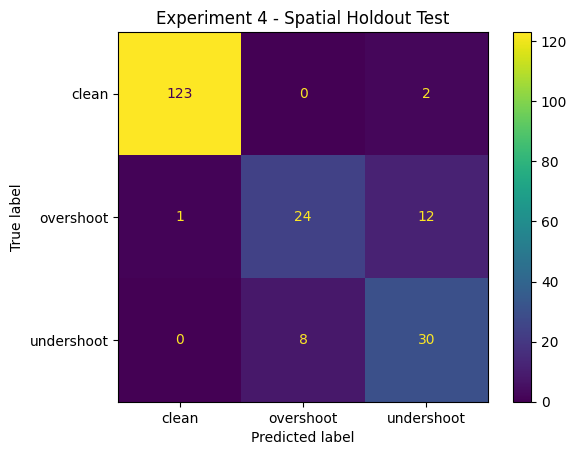

In [ ]:
# Experiment 4: Spatial Holdout Test

# -----------------------------------
# 1) Build spatial coordinates
# -----------------------------------

spatial_df = sim_metric.copy()

spatial_df["centroid_x"] = spatial_df.geometry.centroid.x
spatial_df["centroid_y"] = spatial_df.geometry.centroid.y

# نستخدم نفس Features الخاصة بـ Experiment 3
X4 = X3.copy()
y4 = y3.copy()

# نضيف الإحداثيات فقط عشان نسوي split
split_df = pd.DataFrame({
    "x": spatial_df["centroid_x"].values,
    "y": spatial_df["centroid_y"].values,
    "label": y4.values
})

# -----------------------------------
# 2) Spatial split
# -----------------------------------

# نقسم حسب X:
# 80% من الجهة الغربية/الوسطى للتدريب
# 20% من الجهة الشرقية للاختبار

x_threshold = split_df["x"].quantile(0.80)

train_idx = split_df[
    split_df["x"] <= x_threshold
].index

test_idx = split_df[
    split_df["x"] > x_threshold
].index

X4_train = X4.loc[train_idx]
y4_train = y4.loc[train_idx]

X4_test = X4.loc[test_idx]
y4_test = y4.loc[test_idx]

print("Spatial Train shape:", X4_train.shape)
print("Spatial Test shape:", X4_test.shape)

print("\nTrain class distribution:")
print(y4_train.value_counts().sort_index())

print("\nTest class distribution:")
print(y4_test.value_counts().sort_index())

# -----------------------------------
# 3) Balanced weights
# -----------------------------------

sample_weights4 = compute_sample_weight(
    class_weight="balanced",
    y=y4_train
)

# -----------------------------------
# 4) Train XGBoost
# -----------------------------------

model4 = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=SEED,
    n_jobs=-1
)

model4.fit(
    X4_train,
    y4_train,
    sample_weight=sample_weights4
)

# -----------------------------------
# 5) Evaluate on unseen spatial area
# -----------------------------------

y4_pred = model4.predict(X4_test)

print("\n===== SPATIAL HOLDOUT TEST =====")

print(
    "Accuracy:",
    round(accuracy_score(y4_test, y4_pred), 4)
)

print(
    "Balanced Accuracy:",
    round(
        balanced_accuracy_score(
            y4_test,
            y4_pred
        ),
        4
    )
)

print(
    classification_report(
        y4_test,
        y4_pred,
        labels=[0, 1, 2],
        target_names=[
            "clean",
            "overshoot",
            "undershoot"
        ],
        digits=4,
        zero_division=0
    )
)

# -----------------------------------
# 6) Confusion Matrix
# -----------------------------------

cm4 = confusion_matrix(
    y4_test,
    y4_pred,
    labels=[0, 1, 2]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm4,
    display_labels=[
        "clean",
        "overshoot",
        "undershoot"
    ]
)

disp.plot(values_format="d")
plt.title("Experiment 4 - Spatial Holdout Test")
plt.show()

===== FEATURE IMPORTANCE =====
                        feature  importance
13               start_dangling    0.296844
14                 end_dangling    0.179673
10        end_nearest_road_dist    0.118056
9       start_nearest_road_dist    0.085567
4                    end_degree    0.061862
6                    min_degree    0.051605
12    end_nearest_endpoint_dist    0.050281
11  start_nearest_endpoint_dist    0.041210
2                  num_vertices    0.027277
0                 road_length_m    0.020900
1                  straightness    0.019132
7            start_nearby_roads    0.012959
5                    max_degree    0.012266
3                  start_degree    0.012096
8              end_nearby_roads    0.010270


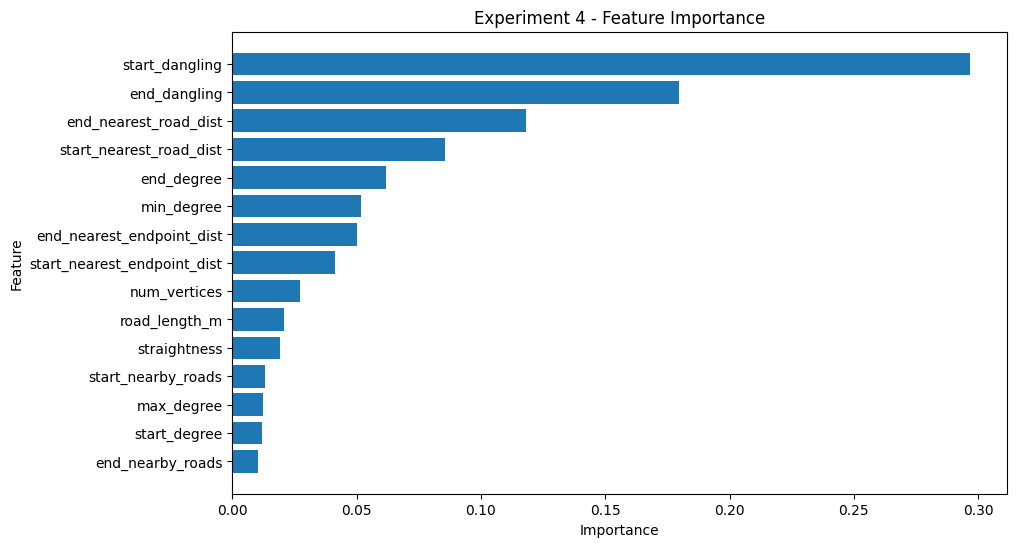

In [ ]:
# Feature Importance - Experiment 4

import pandas as pd
import matplotlib.pyplot as plt

importance_df = pd.DataFrame({
    "feature": X4.columns,
    "importance": model4.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

print("===== FEATURE IMPORTANCE =====")
print(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Experiment 4 - Feature Importance")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Experiment 5: Sensitivity Analysis
# Test different search_radius and dangling_threshold values

from shapely.strtree import STRtree
from shapely.geometry import Point
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier
import pandas as pd

# ---------------------------------------------------
# 1) Geometry setup
# ---------------------------------------------------

road_geoms = list(sim_metric.geometry)
tree = STRtree(road_geoms)

def get_endpoints(geom):
    coords = list(geom.coords)
    return Point(coords[0]), Point(coords[-1])


# ---------------------------------------------------
# 2) Feature extraction function
# ---------------------------------------------------

def extract_local_features(search_radius, dangling_threshold):

    rows = []

    for row_idx, geom in enumerate(road_geoms):

        start_pt, end_pt = get_endpoints(geom)

        start_candidates = [
            i for i in tree.query(start_pt.buffer(search_radius))
            if i != row_idx
        ]

        end_candidates = [
            i for i in tree.query(end_pt.buffer(search_radius))
            if i != row_idx
        ]

        # ---------------------------
        # Nearest road distance
        # ---------------------------

        if start_candidates:
            start_nearest_road_dist = min(
                start_pt.distance(road_geoms[i])
                for i in start_candidates
            )
        else:
            start_nearest_road_dist = search_radius

        if end_candidates:
            end_nearest_road_dist = min(
                end_pt.distance(road_geoms[i])
                for i in end_candidates
            )
        else:
            end_nearest_road_dist = search_radius

        # ---------------------------
        # Nearest endpoint distance
        # ---------------------------

        start_other_endpoints = []

        for i in start_candidates:
            p1, p2 = get_endpoints(road_geoms[i])
            start_other_endpoints.extend([p1, p2])

        if start_other_endpoints:
            start_nearest_endpoint_dist = min(
                start_pt.distance(p)
                for p in start_other_endpoints
            )
        else:
            start_nearest_endpoint_dist = search_radius

        end_other_endpoints = []

        for i in end_candidates:
            p1, p2 = get_endpoints(road_geoms[i])
            end_other_endpoints.extend([p1, p2])

        if end_other_endpoints:
            end_nearest_endpoint_dist = min(
                end_pt.distance(p)
                for p in end_other_endpoints
            )
        else:
            end_nearest_endpoint_dist = search_radius

        # ---------------------------
        # Dangling endpoint
        # ---------------------------

        start_dangling = int(
            start_nearest_road_dist > dangling_threshold
        )

        end_dangling = int(
            end_nearest_road_dist > dangling_threshold
        )

        rows.append({
            "start_nearby_roads": len(start_candidates),
            "end_nearby_roads": len(end_candidates),

            "start_nearest_road_dist":
                start_nearest_road_dist,

            "end_nearest_road_dist":
                end_nearest_road_dist,

            "start_nearest_endpoint_dist":
                start_nearest_endpoint_dist,

            "end_nearest_endpoint_dist":
                end_nearest_endpoint_dist,

            "start_dangling": start_dangling,
            "end_dangling": end_dangling
        })

    return pd.DataFrame(rows)


# ---------------------------------------------------
# 3) Values to test
# ---------------------------------------------------

search_radius_values = [10, 20, 30, 40]
dangling_threshold_values = [1, 2, 3, 5]


basic_features = [
    "road_length_m",
    "straightness",
    "num_vertices",
    "start_degree",
    "end_degree",
    "max_degree",
    "min_degree"
]


# ---------------------------------------------------
# 4) Use SAME spatial split as Experiment 4
# ---------------------------------------------------

train_idx = X4_train.index
test_idx = X4_test.index


results_sensitivity = []


# ---------------------------------------------------
# 5) Run all combinations
# ---------------------------------------------------

for radius in search_radius_values:

    for threshold in dangling_threshold_values:

        print(
            f"Testing radius={radius}m, "
            f"dangling={threshold}m"
        )

        local_temp = extract_local_features(
            search_radius=radius,
            dangling_threshold=threshold
        )

        X_temp = pd.concat(
            [
                features[basic_features].reset_index(drop=True),
                local_temp.reset_index(drop=True)
            ],
            axis=1
        )

        y_temp = y3.copy()

        X_train_temp = X_temp.loc[train_idx]
        X_test_temp = X_temp.loc[test_idx]

        y_train_temp = y_temp.loc[train_idx]
        y_test_temp = y_temp.loc[test_idx]

        weights = compute_sample_weight(
            class_weight="balanced",
            y=y_train_temp
        )

        model_temp = XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            objective="multi:softprob",
            num_class=3,
            eval_metric="mlogloss",
            random_state=SEED,
            n_jobs=-1
        )

        model_temp.fit(
            X_train_temp,
            y_train_temp,
            sample_weight=weights
        )

        pred = model_temp.predict(X_test_temp)

        accuracy = accuracy_score(
            y_test_temp,
            pred
        )

        balanced_acc = balanced_accuracy_score(
            y_test_temp,
            pred
        )

        macro_f1 = f1_score(
            y_test_temp,
            pred,
            average="macro"
        )

        results_sensitivity.append({
            "search_radius_m": radius,
            "dangling_threshold_m": threshold,
            "accuracy": accuracy,
            "balanced_accuracy": balanced_acc,
            "macro_f1": macro_f1
        })


# ---------------------------------------------------
# 6) Results table
# ---------------------------------------------------

sensitivity_df = pd.DataFrame(
    results_sensitivity
)

sensitivity_df = sensitivity_df.sort_values(
    "balanced_accuracy",
    ascending=False
).reset_index(drop=True)

print("\n===== SENSITIVITY ANALYSIS =====")

display(
    sensitivity_df.style.format({
        "accuracy": "{:.4f}",
        "balanced_accuracy": "{:.4f}",
        "macro_f1": "{:.4f}"
    })
)


print("\nBest configuration:")

display(
    sensitivity_df.head(1)
)

Testing radius=10m, dangling=1m
Testing radius=10m, dangling=2m
Testing radius=10m, dangling=3m
Testing radius=10m, dangling=5m
Testing radius=20m, dangling=1m
Testing radius=20m, dangling=2m
Testing radius=20m, dangling=3m
Testing radius=20m, dangling=5m
Testing radius=30m, dangling=1m
Testing radius=30m, dangling=2m
Testing radius=30m, dangling=3m
Testing radius=30m, dangling=5m
Testing radius=40m, dangling=1m
Testing radius=40m, dangling=2m
Testing radius=40m, dangling=3m
Testing radius=40m, dangling=5m

===== SENSITIVITY ANALYSIS =====


,search_radius_m,dangling_threshold_m,accuracy,balanced_accuracy,macro_f1
0,10,2,0.9000,0.8344,0.8325
1,10,5,0.9000,0.8344,0.8306
2,10,1,0.8950,0.8254,0.8234
3,40,2,0.8900,0.8230,0.8191
4,20,5,0.8900,0.8164,0.8141
5,10,3,0.8900,0.8164,0.8143
6,40,1,0.8850,0.8140,0.8101
7,30,1,0.8850,0.8078,0.8060
8,20,2,0.8850,0.8074,0.8051
9,30,3,0.8800,0.8052,0.8017



Best configuration:


,search_radius_m,dangling_threshold_m,accuracy,balanced_accuracy,macro_f1
0,10,2,0.9,0.834401,0.832482


## Experiment 6 — Larger Dataset (5,000 Roads)

Goal:
Test whether the local-topology XGBoost approach remains stable when the road sample is increased from 1,000 to 5,000 roads.

Settings:
- Sample size: 5,000 roads
- Synthetic errors: Topo4Vec
- Search radius: 10 m
- Dangling threshold: 2 m
- Evaluation: Spatial Holdout

In [ ]:
# Experiment 6 — Sample 5,000 connected roads

N_ROADS_EXP6 = 5000

degrees = dict(G.degree())
seed_node = max(degrees, key=degrees.get)

selected_edges_5k = []
visited_nodes_5k = set()
queue = [seed_node]

while queue and len(selected_edges_5k) < N_ROADS_EXP6:

    node = queue.pop(0)

    if node in visited_nodes_5k:
        continue

    visited_nodes_5k.add(node)

    for u, v, key, data in G.edges(
        node,
        keys=True,
        data=True
    ):

        selected_edges_5k.append(
            data["road_index"]
        )

        if v not in visited_nodes_5k:
            queue.append(v)

        if len(selected_edges_5k) >= N_ROADS_EXP6:
            break


selected_edges_5k = list(
    dict.fromkeys(selected_edges_5k)
)[:N_ROADS_EXP6]


roads_sample_5k = (
    roads_valid
    .loc[selected_edges_5k]
    .copy()
    .reset_index(drop=True)
)


print("Seed degree:", degrees[seed_node])
print("Selected roads:", len(roads_sample_5k))

roads_sample_5k.head()

Seed degree: 9
Selected roads: 5000


,id,names,subtype,class,subclass,subclass_rules,connectors,rail_flags,road_surface,road_flags,...,access_restrictions,speed_limits,prohibited_transitions,routes,destinations,sources,version,geometry,start_connector,end_connector
0,66c89f2d-d427-4404-82b0-5485f247eb93,None,road,tertiary,None,None,[{'connector_id': 'ef29c6fe-5ced-43ac-9ee4-1a3...,None,None,None,...,"[{'access_type': 'denied', 'when': {'during': ...",None,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (46.71638 24.70437, 46.7161 24.7040...",ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,13b9d8c9-3276-415e-a852-bb6d8fa33fd4
1,2e29da9a-0778-4ca6-aa62-ad6c87b65426,"{'primary': 'الأمير سلطان بن عبدالعزيز', 'comm...",road,tertiary,None,None,[{'connector_id': 'ef29c6fe-5ced-43ac-9ee4-1a3...,None,"[{'value': 'paved', 'between': None}]",None,...,"[{'access_type': 'denied', 'when': {'during': ...","[{'min_speed': None, 'max_speed': {'value': 70...",None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",2,"LINESTRING (46.71638 24.70437, 46.71589 24.704...",ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,3a1f7954-20da-4506-ad54-5edcdd01f62e
2,ef3337bc-8126-438b-b0f4-71f0c594bd2c,"{'primary': 'Pr. Turki Bin Abdullah Street', '...",road,residential,None,None,[{'connector_id': 'ef29c6fe-5ced-43ac-9ee4-1a3...,None,None,None,...,"[{'access_type': 'denied', 'when': {'during': ...",None,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (46.71638 24.70437, 46.71589 24.70456)",ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,70b48d07-21a5-4942-a13e-c391436d58b4
3,17c3e4da-600a-412f-891b-4da2c9c1a542,"{'primary': 'Al Amir Sultan Ibn Abdul Aziz', '...",road,tertiary,None,None,[{'connector_id': 'ef29c6fe-5ced-43ac-9ee4-1a3...,None,"[ { ""value"": ""paved"", ""between"": [ 0.210157183...",None,...,"[{'access_type': 'designated', 'when': {'durin...","[{'min_speed': None, 'max_speed': {'value': 70...",None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",1,"LINESTRING (46.71638 24.70437, 46.71652 24.704...",ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,1bedac5a-ce7d-498a-a853-3dbcdd297b14
4,68451abb-5d55-41ff-9bbd-0277614605d5,"{'primary': ""Prince Musa'ed Bin Abdulaziz St.""...",road,tertiary,None,None,[{'connector_id': '13b9d8c9-3276-415e-a852-bb6...,None,None,None,...,"[{'access_type': 'denied', 'when': {'during': ...",None,None,None,None,"[{'property': '', 'dataset': 'OpenStreetMap', ...",2,"LINESTRING (46.71586 24.70354, 46.71604 24.703...",13b9d8c9-3276-415e-a852-bb6d8fa33fd4,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7


In [ ]:
# Build graph for the 5,000-road sample

G_sample_5k = nx.MultiDiGraph()

graph_edge_to_id_5k = {}
clean_geometry_5k = []

for local_id, (_, row) in enumerate(
    roads_sample_5k.iterrows()
):

    u = row["start_connector"]
    v = row["end_connector"]

    u_geom = connector_lookup[u]
    v_geom = connector_lookup[v]

    G_sample_5k.add_node(
        u,
        x=u_geom.x,
        y=u_geom.y
    )

    G_sample_5k.add_node(
        v,
        x=v_geom.x,
        y=v_geom.y
    )

    G_sample_5k.add_edge(
        u,
        v,
        key=local_id
    )

    graph_edge_to_id_5k[
        (u, v, local_id)
    ] = local_id

    clean_geometry_5k.append(
        row.geometry
    )


print(
    "Sample nodes:",
    G_sample_5k.number_of_nodes()
)

print(
    "Sample edges:",
    G_sample_5k.number_of_edges()
)

print(
    "Geometries:",
    len(clean_geometry_5k)
)

Sample nodes: 3709
Sample edges: 5000
Geometries: 5000


In [ ]:
# Inject synthetic topology errors

(
    corrupted_geometry_5k,
    corrupted_flags_5k,
    new_corrupted_nodes_5k,
    error_types_5k,
    neighborhood_ids_5k
) = apply_stochastic_errors(

    clean_geometry_5k,
    G_sample_5k,
    graph_edge_to_id_5k,

    error_rate=0.50,
    mu_magnitude=0.4,
    sigma_magnitude=0.3
)


labels_5k = [
    error if error is not None else "clean"
    for error in error_types_5k
]


from collections import Counter

print(
    "Total roads:",
    len(labels_5k)
)

print(
    "Corrupted:",
    sum(corrupted_flags_5k)
)

print(
    "Class distribution:",
    Counter(labels_5k)
)

Target corruption count: 2500 (rate=0.5). Valid candidates: 4777
Corrupted 2072 edges after applying neighbour-protection constraints.
Total roads: 5000
Corrupted: 2072
Class distribution: Counter({'clean': 2928, 'overshoot': 1049, 'undershoot': 1023})


In [ ]:
# Create labeled 5K dataset

sim_5k = roads_sample_5k[
    [
        "id",
        "start_connector",
        "end_connector"
    ]
].copy()


sim_5k["edge_id"] = np.arange(
    len(sim_5k)
)

sim_5k["clean_geometry"] = (
    clean_geometry_5k
)

sim_5k["geometry"] = (
    corrupted_geometry_5k
)

sim_5k["is_corrupted"] = (
    corrupted_flags_5k
)

sim_5k["label"] = labels_5k


sim_gdf_5k = gpd.GeoDataFrame(
    sim_5k,
    geometry="geometry",
    crs=roads_sample_5k.crs
)


print(
    sim_gdf_5k["label"].value_counts()
)

sim_gdf_5k.head()

label
clean         2928
overshoot     1049
undershoot    1023
Name: count, dtype: int64


,id,start_connector,end_connector,edge_id,clean_geometry,geometry,is_corrupted,label
0,66c89f2d-d427-4404-82b0-5485f247eb93,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,13b9d8c9-3276-415e-a852-bb6d8fa33fd4,0,"LINESTRING (46.7163824 24.7043667, 46.7161033 ...","LINESTRING (46.71638 24.70437, 46.7161 24.7040...",False,clean
1,2e29da9a-0778-4ca6-aa62-ad6c87b65426,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,3a1f7954-20da-4506-ad54-5edcdd01f62e,1,"LINESTRING (46.7163824 24.7043667, 46.7158888 ...","LINESTRING (46.71657 24.70442, 46.71589 24.704...",True,overshoot
2,ef3337bc-8126-438b-b0f4-71f0c594bd2c,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,70b48d07-21a5-4942-a13e-c391436d58b4,2,"LINESTRING (46.7163824 24.7043667, 46.7158938 ...","LINESTRING (46.71638 24.70437, 46.71589 24.70456)",False,clean
3,17c3e4da-600a-412f-891b-4da2c9c1a542,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,1bedac5a-ce7d-498a-a853-3dbcdd297b14,3,"LINESTRING (46.7163824 24.7043667, 46.7165194 ...","LINESTRING (46.71638 24.70437, 46.71652 24.704...",False,clean
4,68451abb-5d55-41ff-9bbd-0277614605d5,13b9d8c9-3276-415e-a852-bb6d8fa33fd4,ef29c6fe-5ced-43ac-9ee4-1a3c53371db7,4,"LINESTRING (46.7158594 24.70354, 46.7160374 24...","LINESTRING (46.71586 24.70354, 46.71604 24.703...",False,clean


In [ ]:
# Project to metric CRS

METRIC_CRS = "EPSG:32638"

sim_metric_5k = sim_gdf_5k.to_crs(
    METRIC_CRS
)

connectors_metric_5k = connectors.to_crs(
    METRIC_CRS
)

degree_undirected_5k = dict(
    G_sample_5k
    .to_undirected()
    .degree()
)

print(
    "Metric CRS:",
    sim_metric_5k.crs
)

Metric CRS: EPSG:32638


In [ ]:
from shapely.geometry import Point
import numpy as np
import pandas as pd


basic_rows_5k = []


for _, row in sim_metric_5k.iterrows():

    geom = row.geometry

    coords = list(geom.coords)

    start_pt = Point(coords[0])
    end_pt = Point(coords[-1])

    road_length = geom.length

    direct_distance = (
        start_pt.distance(end_pt)
    )

    straightness = (
        direct_distance / road_length
        if road_length > 0
        else 0
    )

    start_connector = (
        row["start_connector"]
    )

    end_connector = (
        row["end_connector"]
    )

    start_degree = (
        degree_undirected_5k.get(
            start_connector,
            0
        )
    )

    end_degree = (
        degree_undirected_5k.get(
            end_connector,
            0
        )
    )

    basic_rows_5k.append({

        "road_length_m":
            road_length,

        "straightness":
            straightness,

        "num_vertices":
            len(coords),

        "start_degree":
            start_degree,

        "end_degree":
            end_degree,

        "max_degree":
            max(
                start_degree,
                end_degree
            ),

        "min_degree":
            min(
                start_degree,
                end_degree
            )
    })


basic_features_5k = pd.DataFrame(
    basic_rows_5k
)


basic_features_5k.head()

,road_length_m,straightness,num_vertices,start_degree,end_degree,max_degree,min_degree
0,106.286238,0.995071,3,9,4,9,4
1,180.519374,0.991869,4,9,3,9,3
2,53.970123,1.000000,2,9,3,9,3
3,186.807429,0.997380,5,9,3,9,3
4,106.463420,0.993415,5,4,9,9,4


In [ ]:
# Local topology features

from shapely.strtree import STRtree


SEARCH_RADIUS = 10
DANGLING_THRESHOLD = 2


road_geoms_5k = list(
    sim_metric_5k.geometry
)

tree_5k = STRtree(
    road_geoms_5k
)


def endpoints_5k(geom):

    coords = list(geom.coords)

    return (
        Point(coords[0]),
        Point(coords[-1])
    )


local_rows_5k = []


for row_idx, geom in enumerate(
    road_geoms_5k
):

    start_pt, end_pt = (
        endpoints_5k(geom)
    )

    start_candidates = [
        int(i)
        for i in tree_5k.query(
            start_pt.buffer(
                SEARCH_RADIUS
            )
        )
        if int(i) != row_idx
    ]

    end_candidates = [
        int(i)
        for i in tree_5k.query(
            end_pt.buffer(
                SEARCH_RADIUS
            )
        )
        if int(i) != row_idx
    ]


    # -------------------------
    # Nearest road
    # -------------------------

    if start_candidates:

        start_nearest_road_dist = min(
            start_pt.distance(
                road_geoms_5k[i]
            )
            for i
            in start_candidates
        )

    else:
        start_nearest_road_dist = (
            SEARCH_RADIUS
        )


    if end_candidates:

        end_nearest_road_dist = min(
            end_pt.distance(
                road_geoms_5k[i]
            )
            for i
            in end_candidates
        )

    else:
        end_nearest_road_dist = (
            SEARCH_RADIUS
        )


    # -------------------------
    # Nearest endpoint
    # -------------------------

    start_endpoint_distances = []

    for i in start_candidates:

        p1, p2 = endpoints_5k(
            road_geoms_5k[i]
        )

        start_endpoint_distances.extend([
            start_pt.distance(p1),
            start_pt.distance(p2)
        ])


    if start_endpoint_distances:

        start_nearest_endpoint_dist = min(
            start_endpoint_distances
        )

    else:
        start_nearest_endpoint_dist = (
            SEARCH_RADIUS
        )


    end_endpoint_distances = []

    for i in end_candidates:

        p1, p2 = endpoints_5k(
            road_geoms_5k[i]
        )

        end_endpoint_distances.extend([
            end_pt.distance(p1),
            end_pt.distance(p2)
        ])


    if end_endpoint_distances:

        end_nearest_endpoint_dist = min(
            end_endpoint_distances
        )

    else:
        end_nearest_endpoint_dist = (
            SEARCH_RADIUS
        )


    # -------------------------
    # Dangling
    # -------------------------

    start_dangling = int(
        start_nearest_road_dist >
        DANGLING_THRESHOLD
    )

    end_dangling = int(
        end_nearest_road_dist >
        DANGLING_THRESHOLD
    )


    local_rows_5k.append({

        "start_nearby_roads":
            len(start_candidates),

        "end_nearby_roads":
            len(end_candidates),

        "start_nearest_road_dist":
            start_nearest_road_dist,

        "end_nearest_road_dist":
            end_nearest_road_dist,

        "start_nearest_endpoint_dist":
            start_nearest_endpoint_dist,

        "end_nearest_endpoint_dist":
            end_nearest_endpoint_dist,

        "start_dangling":
            start_dangling,

        "end_dangling":
            end_dangling
    })


local_features_5k = pd.DataFrame(
    local_rows_5k
)


print(
    local_features_5k.shape
)

local_features_5k.head()

(5000, 8)


,start_nearby_roads,end_nearby_roads,start_nearest_road_dist,end_nearest_road_dist,start_nearest_endpoint_dist,end_nearest_endpoint_dist,start_dangling,end_dangling
0,10,5,0.000000,0.0,0.000000,0.0,0,0
1,4,5,9.077065,0.0,20.082012,0.0,1,0
2,10,5,0.000000,0.0,0.000000,0.0,0,0
3,10,7,0.000000,0.0,0.000000,0.0,0,0
4,5,10,0.000000,0.0,0.000000,0.0,0,0


In [ ]:
# Combine all Experiment 6 features

features_5k = pd.concat(
    [
        basic_features_5k.reset_index(
            drop=True
        ),

        local_features_5k.reset_index(
            drop=True
        )
    ],
    axis=1
)


CLASS_TO_ID = {
    "clean": 0,
    "overshoot": 1,
    "undershoot": 2
}

ID_TO_CLASS = {
    v: k
    for k, v
    in CLASS_TO_ID.items()
}


y_5k = (
    sim_metric_5k["label"]
    .map(CLASS_TO_ID)
    .reset_index(drop=True)
)


X_5k = features_5k.copy()


print(
    "X:",
    X_5k.shape
)

print(
    "\ny:"
)

print(
    y_5k.value_counts()
)

X: (5000, 15)

y:
label
0    2928
1    1049
2    1023
Name: count, dtype: int64


In [ ]:
# Spatial Holdout

centroid_x_5k = (
    sim_metric_5k.geometry
    .centroid
    .x
)


spatial_threshold_5k = (
    centroid_x_5k.quantile(0.80)
)


train_mask_5k = (
    centroid_x_5k <=
    spatial_threshold_5k
)

test_mask_5k = (
    centroid_x_5k >
    spatial_threshold_5k
)


X_train_5k = (
    X_5k.loc[train_mask_5k]
    .copy()
)

X_test_5k = (
    X_5k.loc[test_mask_5k]
    .copy()
)


y_train_5k = (
    y_5k.loc[train_mask_5k]
    .copy()
)

y_test_5k = (
    y_5k.loc[test_mask_5k]
    .copy()
)


print(
    "Train:",
    X_train_5k.shape
)

print(
    "Test:",
    X_test_5k.shape
)

print(
    "\nTrain distribution:"
)

print(
    y_train_5k.value_counts()
)

print(
    "\nTest distribution:"
)

print(
    y_test_5k.value_counts()
)

Train: (4000, 15)
Test: (1000, 15)

Train distribution:
label
0    2332
1     844
2     824
Name: count, dtype: int64

Test distribution:
label
0    596
1    205
2    199
Name: count, dtype: int64


In [ ]:
# Train XGBoost

from sklearn.utils.class_weight import (
    compute_sample_weight
)

from xgboost import XGBClassifier


weights_5k = compute_sample_weight(
    class_weight="balanced",
    y=y_train_5k
)


model_5k = XGBClassifier(

    n_estimators=300,

    max_depth=4,

    learning_rate=0.05,

    subsample=0.9,

    colsample_bytree=0.9,

    objective="multi:softprob",

    num_class=3,

    eval_metric="mlogloss",

    random_state=SEED,

    n_jobs=-1
)


model_5k.fit(

    X_train_5k,

    y_train_5k,

    sample_weight=weights_5k
)


print(
    "Training complete"
)

Training complete


In [ ]:
# Evaluate 5K spatial holdout

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)


pred_5k = model_5k.predict(
    X_test_5k
)


acc_5k = accuracy_score(
    y_test_5k,
    pred_5k
)

balanced_acc_5k = (
    balanced_accuracy_score(
        y_test_5k,
        pred_5k
    )
)


print(
    "Accuracy:",
    round(acc_5k, 4)
)

print(
    "Balanced Accuracy:",
    round(
        balanced_acc_5k,
        4
    )
)


print(
    "\nClassification Report:\n"
)

print(
    classification_report(
        y_test_5k,
        pred_5k,
        target_names=[
            "clean",
            "overshoot",
            "undershoot"
        ],
        digits=4
    )
)


print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_test_5k,
        pred_5k
    )
)

Accuracy: 0.916
Balanced Accuracy: 0.872

Classification Report:

              precision    recall  f1-score   support

       clean     0.9966    0.9832    0.9899       596
   overshoot     0.7864    0.8439    0.8141       205
  undershoot     0.8177    0.7889    0.8031       199

    accuracy                         0.9160      1000
   macro avg     0.8669    0.8720    0.8690      1000
weighted avg     0.9179    0.9160    0.9167      1000


Confusion Matrix:
[[586   5   5]
 [  2 173  30]
 [  0  42 157]]


In [ ]:
comparison = pd.DataFrame({

    "Experiment": [
        "1,000 Roads",
        "5,000 Roads"
    ],

    "Accuracy": [
        0.885,
        acc_5k
    ],

    "Balanced Accuracy": [
        0.8074,
        balanced_acc_5k
    ]
})


comparison

,Experiment,Accuracy,Balanced Accuracy
0,"1,000 Roads",0.885,0.807400
1,"5,000 Roads",0.916,0.872023


In [ ]:
# ============================================================
# Experiment 7 — 10,000 Roads
# Same pipeline as 5K experiment
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx

from collections import Counter
from shapely.geometry import Point
from shapely.strtree import STRtree

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)
from xgboost import XGBClassifier


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

N_ROADS = 10000
SEARCH_RADIUS = 10
DANGLING_THRESHOLD = 2
METRIC_CRS = "EPSG:32638"


# ------------------------------------------------------------
# 1. Sample 10,000 connected roads
# ------------------------------------------------------------

degrees = dict(G.degree())
seed_node = max(degrees, key=degrees.get)

selected_edges_10k = []
visited_nodes_10k = set()
queue = [seed_node]

while queue and len(selected_edges_10k) < N_ROADS:

    node = queue.pop(0)

    if node in visited_nodes_10k:
        continue

    visited_nodes_10k.add(node)

    for u, v, key, data in G.edges(
        node,
        keys=True,
        data=True
    ):

        selected_edges_10k.append(
            data["road_index"]
        )

        if v not in visited_nodes_10k:
            queue.append(v)

        if len(selected_edges_10k) >= N_ROADS:
            break


selected_edges_10k = list(
    dict.fromkeys(selected_edges_10k)
)[:N_ROADS]

roads_sample_10k = (
    roads_valid
    .loc[selected_edges_10k]
    .copy()
    .reset_index(drop=True)
)

print("Selected roads:", len(roads_sample_10k))


# ------------------------------------------------------------
# 2. Build sample graph
# ------------------------------------------------------------

G_sample_10k = nx.MultiDiGraph()

graph_edge_to_id_10k = {}
clean_geometry_10k = []

for local_id, (_, row) in enumerate(
    roads_sample_10k.iterrows()
):

    u = row["start_connector"]
    v = row["end_connector"]

    u_geom = connector_lookup[u]
    v_geom = connector_lookup[v]

    G_sample_10k.add_node(
        u,
        x=u_geom.x,
        y=u_geom.y
    )

    G_sample_10k.add_node(
        v,
        x=v_geom.x,
        y=v_geom.y
    )

    G_sample_10k.add_edge(
        u,
        v,
        key=local_id
    )

    graph_edge_to_id_10k[
        (u, v, local_id)
    ] = local_id

    clean_geometry_10k.append(
        row.geometry
    )


# ------------------------------------------------------------
# 3. Synthetic error injection
# ------------------------------------------------------------

(
    corrupted_geometry_10k,
    corrupted_flags_10k,
    new_corrupted_nodes_10k,
    error_types_10k,
    neighborhood_ids_10k
) = apply_stochastic_errors(

    clean_geometry_10k,
    G_sample_10k,
    graph_edge_to_id_10k,

    error_rate=0.50,
    mu_magnitude=0.4,
    sigma_magnitude=0.3
)


labels_10k = [
    e if e is not None else "clean"
    for e in error_types_10k
]

print("Class distribution:", Counter(labels_10k))


# ------------------------------------------------------------
# 4. Build labeled GeoDataFrame
# ------------------------------------------------------------

sim_10k = roads_sample_10k[
    [
        "id",
        "start_connector",
        "end_connector"
    ]
].copy()

sim_10k["edge_id"] = np.arange(len(sim_10k))
sim_10k["clean_geometry"] = clean_geometry_10k
sim_10k["geometry"] = corrupted_geometry_10k
sim_10k["is_corrupted"] = corrupted_flags_10k
sim_10k["label"] = labels_10k

sim_gdf_10k = gpd.GeoDataFrame(
    sim_10k,
    geometry="geometry",
    crs=roads_sample_10k.crs
)

sim_metric_10k = sim_gdf_10k.to_crs(
    METRIC_CRS
)

degree_undirected_10k = dict(
    G_sample_10k
    .to_undirected()
    .degree()
)


# ------------------------------------------------------------
# 5. Basic features
# ------------------------------------------------------------

basic_rows = []

for _, row in sim_metric_10k.iterrows():

    geom = row.geometry
    coords = list(geom.coords)

    start_pt = Point(coords[0])
    end_pt = Point(coords[-1])

    road_length = geom.length
    direct_distance = start_pt.distance(end_pt)

    straightness = (
        direct_distance / road_length
        if road_length > 0
        else 0
    )

    start_degree = degree_undirected_10k.get(
        row["start_connector"],
        0
    )

    end_degree = degree_undirected_10k.get(
        row["end_connector"],
        0
    )

    basic_rows.append({

        "road_length_m": road_length,

        "straightness": straightness,

        "num_vertices": len(coords),

        "start_degree": start_degree,

        "end_degree": end_degree,

        "max_degree": max(
            start_degree,
            end_degree
        ),

        "min_degree": min(
            start_degree,
            end_degree
        )
    })


basic_features_10k = pd.DataFrame(
    basic_rows
)


# ------------------------------------------------------------
# 6. Local topology features
# ------------------------------------------------------------

road_geoms = list(
    sim_metric_10k.geometry
)

tree = STRtree(road_geoms)


def get_endpoints(geom):

    coords = list(geom.coords)

    return (
        Point(coords[0]),
        Point(coords[-1])
    )


local_rows = []

for row_idx, geom in enumerate(road_geoms):

    start_pt, end_pt = get_endpoints(
        geom
    )

    start_candidates = [
        int(i)
        for i in tree.query(
            start_pt.buffer(
                SEARCH_RADIUS
            )
        )
        if int(i) != row_idx
    ]

    end_candidates = [
        int(i)
        for i in tree.query(
            end_pt.buffer(
                SEARCH_RADIUS
            )
        )
        if int(i) != row_idx
    ]


    if start_candidates:

        start_nearest_road_dist = min(
            start_pt.distance(
                road_geoms[i]
            )
            for i in start_candidates
        )

    else:
        start_nearest_road_dist = SEARCH_RADIUS


    if end_candidates:

        end_nearest_road_dist = min(
            end_pt.distance(
                road_geoms[i]
            )
            for i in end_candidates
        )

    else:
        end_nearest_road_dist = SEARCH_RADIUS


    start_endpoint_distances = []

    for i in start_candidates:

        p1, p2 = get_endpoints(
            road_geoms[i]
        )

        start_endpoint_distances.extend([
            start_pt.distance(p1),
            start_pt.distance(p2)
        ])


    start_nearest_endpoint_dist = (
        min(start_endpoint_distances)
        if start_endpoint_distances
        else SEARCH_RADIUS
    )


    end_endpoint_distances = []

    for i in end_candidates:

        p1, p2 = get_endpoints(
            road_geoms[i]
        )

        end_endpoint_distances.extend([
            end_pt.distance(p1),
            end_pt.distance(p2)
        ])


    end_nearest_endpoint_dist = (
        min(end_endpoint_distances)
        if end_endpoint_distances
        else SEARCH_RADIUS
    )


    local_rows.append({

        "start_nearby_roads":
            len(start_candidates),

        "end_nearby_roads":
            len(end_candidates),

        "start_nearest_road_dist":
            start_nearest_road_dist,

        "end_nearest_road_dist":
            end_nearest_road_dist,

        "start_nearest_endpoint_dist":
            start_nearest_endpoint_dist,

        "end_nearest_endpoint_dist":
            end_nearest_endpoint_dist,

        "start_dangling":
            int(
                start_nearest_road_dist >
                DANGLING_THRESHOLD
            ),

        "end_dangling":
            int(
                end_nearest_road_dist >
                DANGLING_THRESHOLD
            )
    })


local_features_10k = pd.DataFrame(
    local_rows
)


# ------------------------------------------------------------
# 7. Combine features
# ------------------------------------------------------------

X_10k = pd.concat(
    [
        basic_features_10k.reset_index(drop=True),
        local_features_10k.reset_index(drop=True)
    ],
    axis=1
)


CLASS_TO_ID = {
    "clean": 0,
    "overshoot": 1,
    "undershoot": 2
}

y_10k = (
    sim_metric_10k["label"]
    .map(CLASS_TO_ID)
    .reset_index(drop=True)
)

print("Feature shape:", X_10k.shape)


# ------------------------------------------------------------
# 8. Spatial Holdout
# ------------------------------------------------------------

centroid_x = (
    sim_metric_10k.geometry
    .centroid
    .x
)

spatial_threshold = (
    centroid_x.quantile(0.80)
)

train_mask = (
    centroid_x <= spatial_threshold
)

test_mask = (
    centroid_x > spatial_threshold
)


X_train = X_10k.loc[
    train_mask
].copy()

X_test = X_10k.loc[
    test_mask
].copy()

y_train = y_10k.loc[
    train_mask
].copy()

y_test = y_10k.loc[
    test_mask
].copy()

print(
    "Train / Test:",
    X_train.shape,
    X_test.shape
)


# ------------------------------------------------------------
# 9. Train XGBoost
# ------------------------------------------------------------

weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

model_10k = XGBClassifier(

    n_estimators=300,

    max_depth=4,

    learning_rate=0.05,

    subsample=0.9,

    colsample_bytree=0.9,

    objective="multi:softprob",

    num_class=3,

    eval_metric="mlogloss",

    random_state=SEED,

    n_jobs=-1
)

model_10k.fit(
    X_train,
    y_train,
    sample_weight=weights
)


# ------------------------------------------------------------
# 10. Evaluation
# ------------------------------------------------------------

pred_10k = model_10k.predict(
    X_test
)

acc_10k = accuracy_score(
    y_test,
    pred_10k
)

bal_acc_10k = balanced_accuracy_score(
    y_test,
    pred_10k
)


print("\n===== 10K RESULTS =====")

print(
    "Accuracy:",
    round(acc_10k, 4)
)

print(
    "Balanced Accuracy:",
    round(bal_acc_10k, 4)
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        pred_10k,
        target_names=[
            "clean",
            "overshoot",
            "undershoot"
        ],
        digits=4
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        pred_10k
    )
)


# ------------------------------------------------------------
# 11. Compare 1K vs 5K vs 10K
# ------------------------------------------------------------

comparison_10k = pd.DataFrame({

    "Dataset Size": [
        1000,
        5000,
        10000
    ],

    "Accuracy": [
        0.885,
        0.916,
        acc_10k
    ],

    "Balanced Accuracy": [
        0.8074,
        0.872023,
        bal_acc_10k
    ]
})

display(comparison_10k)

Selected roads: 10000
Target corruption count: 5000 (rate=0.5). Valid candidates: 9605
Corrupted 4181 edges after applying neighbour-protection constraints.
Class distribution: Counter({'clean': 5819, 'overshoot': 2139, 'undershoot': 2042})
Feature shape: (10000, 15)
Train / Test: (8000, 15) (2000, 15)

===== 10K RESULTS =====
Accuracy: 0.9195
Balanced Accuracy: 0.8806

Classification Report:

              precision    recall  f1-score   support

       clean     0.9890    0.9798    0.9844      1191
   overshoot     0.8228    0.8169    0.8198       415
  undershoot     0.8162    0.8452    0.8304       394

    accuracy                         0.9195      2000
   macro avg     0.8760    0.8806    0.8782      2000
weighted avg     0.9205    0.9195    0.9199      2000


Confusion Matrix:
[[1167   14   10]
 [  11  339   65]
 [   2   59  333]]


,Dataset Size,Accuracy,Balanced Accuracy
0,1000,0.8850,0.807400
1,5000,0.9160,0.872023
2,10000,0.9195,0.880631


In [ ]:
# ============================================================
# Experiment 8 — Unseen Error Generation
# No Topo4Vec for error generation
# No retraining
# Evaluate the existing model_10k
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd

from shapely.geometry import Point, LineString
from shapely.ops import substring
from shapely.strtree import STRtree

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

SEED_SHIFT = 123
rng = np.random.default_rng(SEED_SHIFT)

N_PER_CLASS = 300

SEARCH_RADIUS = 10
DANGLING_THRESHOLD = 2

MIN_SHIFT_M = 1.0
MAX_SHIFT_M = 12.0


# ------------------------------------------------------------
# 1. Use ONLY roads from the previous spatial test area
# ------------------------------------------------------------

test_indices_all = np.flatnonzero(
    np.asarray(test_mask)
)

if len(test_indices_all) < N_PER_CLASS * 3:
    raise ValueError(
        f"Need at least {N_PER_CLASS*3} test roads, "
        f"but only {len(test_indices_all)} are available."
    )

selected_shift_idx = rng.choice(
    test_indices_all,
    size=N_PER_CLASS * 3,
    replace=False
)

clean_idx = selected_shift_idx[:N_PER_CLASS]

overshoot_idx = selected_shift_idx[
    N_PER_CLASS:2*N_PER_CLASS
]

undershoot_idx = selected_shift_idx[
    2*N_PER_CLASS:
]


# ------------------------------------------------------------
# 2. Start from ORIGINAL CLEAN roads in metric CRS
# ------------------------------------------------------------

clean_metric_10k = (
    roads_sample_10k
    .to_crs(METRIC_CRS)
    .geometry
    .reset_index(drop=True)
)

shift_geoms = list(
    clean_metric_10k.copy()
)

shift_labels = np.array(
    ["ignore"] * len(shift_geoms),
    dtype=object
)

shift_labels[clean_idx] = "clean"
shift_labels[overshoot_idx] = "overshoot"
shift_labels[undershoot_idx] = "undershoot"


# ------------------------------------------------------------
# 3. Custom error generator
# ------------------------------------------------------------

def extend_endpoint(line, at_start, distance):

    coords = list(line.coords)

    if len(coords) < 2:
        return line

    if at_start:

        p0 = np.array(coords[0][:2], dtype=float)
        p1 = np.array(coords[1][:2], dtype=float)

        direction = p0 - p1

        norm = np.linalg.norm(direction)

        if norm == 0:
            return line

        direction = direction / norm

        new_point = (
            p0 + direction * distance
        )

        new_coords = [
            tuple(new_point),
            *coords
        ]

    else:

        p0 = np.array(coords[-1][:2], dtype=float)
        p1 = np.array(coords[-2][:2], dtype=float)

        direction = p0 - p1

        norm = np.linalg.norm(direction)

        if norm == 0:
            return line

        direction = direction / norm

        new_point = (
            p0 + direction * distance
        )

        new_coords = [
            *coords,
            tuple(new_point)
        ]

    return LineString(new_coords)


def shorten_endpoint(line, at_start, distance):

    length = line.length

    # Prevent invalid/empty short roads
    max_allowed = max(
        0.5,
        length * 0.35
    )

    distance = min(
        distance,
        max_allowed
    )

    if distance >= length:
        return line

    if at_start:

        new_geom = substring(
            line,
            distance,
            length
        )

    else:

        new_geom = substring(
            line,
            0,
            length - distance
        )

    if (
        new_geom.is_empty
        or new_geom.geom_type != "LineString"
    ):
        return line

    return new_geom


# ------------------------------------------------------------
# 4. Generate NEW Overshoot errors
# ------------------------------------------------------------

for idx in overshoot_idx:

    geom = clean_metric_10k.iloc[idx]

    distance = rng.uniform(
        MIN_SHIFT_M,
        MAX_SHIFT_M
    )

    at_start = bool(
        rng.integers(0, 2)
    )

    shift_geoms[idx] = extend_endpoint(
        geom,
        at_start,
        distance
    )


# ------------------------------------------------------------
# 5. Generate NEW Undershoot errors
# ------------------------------------------------------------

for idx in undershoot_idx:

    geom = clean_metric_10k.iloc[idx]

    distance = rng.uniform(
        MIN_SHIFT_M,
        MAX_SHIFT_M
    )

    at_start = bool(
        rng.integers(0, 2)
    )

    shift_geoms[idx] = shorten_endpoint(
        geom,
        at_start,
        distance
    )


print("Custom evaluation data:")
print("Clean:", len(clean_idx))
print("Overshoot:", len(overshoot_idx))
print("Undershoot:", len(undershoot_idx))


# ------------------------------------------------------------
# 6. Build spatial index using CURRENT geometries
# ------------------------------------------------------------

tree_shift = STRtree(
    shift_geoms
)


def endpoints_shift(geom):

    coords = list(geom.coords)

    return (
        Point(coords[0]),
        Point(coords[-1])
    )


# ------------------------------------------------------------
# 7. Extract EXACT SAME 15 features
# ------------------------------------------------------------

feature_rows_shift = []


for row_idx in selected_shift_idx:

    geom = shift_geoms[row_idx]

    coords = list(geom.coords)

    start_pt = Point(coords[0])
    end_pt = Point(coords[-1])

    # ------------------------
    # Basic features
    # ------------------------

    road_length = geom.length

    direct_distance = (
        start_pt.distance(end_pt)
    )

    straightness = (
        direct_distance / road_length
        if road_length > 0
        else 0
    )

    original_row = (
        roads_sample_10k.iloc[row_idx]
    )

    start_degree = (
        degree_undirected_10k.get(
            original_row["start_connector"],
            0
        )
    )

    end_degree = (
        degree_undirected_10k.get(
            original_row["end_connector"],
            0
        )
    )


    # ------------------------
    # Local road context
    # ------------------------

    start_candidates = [
        int(i)
        for i in tree_shift.query(
            start_pt.buffer(
                SEARCH_RADIUS
            )
        )
        if int(i) != row_idx
    ]

    end_candidates = [
        int(i)
        for i in tree_shift.query(
            end_pt.buffer(
                SEARCH_RADIUS
            )
        )
        if int(i) != row_idx
    ]


    if start_candidates:

        start_nearest_road_dist = min(
            start_pt.distance(
                shift_geoms[i]
            )
            for i in start_candidates
        )

    else:
        start_nearest_road_dist = SEARCH_RADIUS


    if end_candidates:

        end_nearest_road_dist = min(
            end_pt.distance(
                shift_geoms[i]
            )
            for i in end_candidates
        )

    else:
        end_nearest_road_dist = SEARCH_RADIUS


    # ------------------------
    # Nearest endpoint
    # ------------------------

    start_endpoint_distances = []

    for i in start_candidates:

        p1, p2 = endpoints_shift(
            shift_geoms[i]
        )

        start_endpoint_distances.extend([
            start_pt.distance(p1),
            start_pt.distance(p2)
        ])

    start_nearest_endpoint_dist = (
        min(start_endpoint_distances)
        if start_endpoint_distances
        else SEARCH_RADIUS
    )


    end_endpoint_distances = []

    for i in end_candidates:

        p1, p2 = endpoints_shift(
            shift_geoms[i]
        )

        end_endpoint_distances.extend([
            end_pt.distance(p1),
            end_pt.distance(p2)
        ])

    end_nearest_endpoint_dist = (
        min(end_endpoint_distances)
        if end_endpoint_distances
        else SEARCH_RADIUS
    )


    feature_rows_shift.append({

        "road_length_m":
            road_length,

        "straightness":
            straightness,

        "num_vertices":
            len(coords),

        "start_degree":
            start_degree,

        "end_degree":
            end_degree,

        "max_degree":
            max(start_degree, end_degree),

        "min_degree":
            min(start_degree, end_degree),

        "start_nearby_roads":
            len(start_candidates),

        "end_nearby_roads":
            len(end_candidates),

        "start_nearest_road_dist":
            start_nearest_road_dist,

        "end_nearest_road_dist":
            end_nearest_road_dist,

        "start_nearest_endpoint_dist":
            start_nearest_endpoint_dist,

        "end_nearest_endpoint_dist":
            end_nearest_endpoint_dist,

        "start_dangling":
            int(
                start_nearest_road_dist >
                DANGLING_THRESHOLD
            ),

        "end_dangling":
            int(
                end_nearest_road_dist >
                DANGLING_THRESHOLD
            )
    })


X_shift = pd.DataFrame(
    feature_rows_shift
)

# Force exact same feature order used by model
X_shift = X_shift[
    X_train.columns
]


# ------------------------------------------------------------
# 8. Ground Truth
# ------------------------------------------------------------

CLASS_TO_ID = {
    "clean": 0,
    "overshoot": 1,
    "undershoot": 2
}

y_shift = np.array([
    CLASS_TO_ID[
        shift_labels[i]
    ]
    for i in selected_shift_idx
])


# ------------------------------------------------------------
# 9. IMPORTANT:
# Use the EXISTING trained 10K model.
# NO model.fit() here.
# ------------------------------------------------------------

pred_shift = model_10k.predict(
    X_shift
)


# ------------------------------------------------------------
# 10. Evaluation
# ------------------------------------------------------------

shift_acc = accuracy_score(
    y_shift,
    pred_shift
)

shift_bal_acc = balanced_accuracy_score(
    y_shift,
    pred_shift
)


print("\n===== UNSEEN ERROR GENERATION RESULTS =====")

print(
    "Accuracy:",
    round(shift_acc, 4)
)

print(
    "Balanced Accuracy:",
    round(shift_bal_acc, 4)
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_shift,
        pred_shift,
        target_names=[
            "clean",
            "overshoot",
            "undershoot"
        ],
        digits=4
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_shift,
        pred_shift
    )
)

Custom evaluation data:
Clean: 300
Overshoot: 300
Undershoot: 300

===== UNSEEN ERROR GENERATION RESULTS =====
Accuracy: 0.7122
Balanced Accuracy: 0.7122

Classification Report:

              precision    recall  f1-score   support

       clean     0.7772    0.9767    0.8656       300
   overshoot     0.6643    0.6133    0.6378       300
  undershoot     0.6667    0.5467    0.6007       300

    accuracy                         0.7122       900
   macro avg     0.7027    0.7122    0.7014       900
weighted avg     0.7027    0.7122    0.7014       900


Confusion Matrix:
[[293   3   4]
 [ 38 184  78]
 [ 46  90 164]]


In [ ]:
# ============================================================
# Experiment 9 — Multi-Generator Training + New Unseen Test
# ============================================================

import numpy as np
import pandas as pd

from shapely.geometry import Point, LineString
from shapely.ops import substring
from shapely.strtree import STRtree

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from xgboost import XGBClassifier


# ============================================================
# SETTINGS
# ============================================================

RNG = np.random.default_rng(777)

SEARCH_RADIUS = 10
DANGLING_THRESHOLD = 2

# Add 1000 custom Overshoot + 1000 custom Undershoot
N_AUG_PER_ERROR = 1000

# New final test:
# 300 clean + 300 overshoot + 300 undershoot
N_TEST_PER_CLASS = 300


# ============================================================
# 1. ORIGINAL CLEAN GEOMETRIES
# ============================================================

clean_metric_all = (
    roads_sample_10k
    .to_crs(METRIC_CRS)
    .geometry
    .reset_index(drop=True)
)

n_total = len(clean_metric_all)

print("Total roads available:", n_total)


# ============================================================
# 2. CUSTOM ERROR FUNCTIONS
# ============================================================

def extend_endpoint_custom(line, at_start, distance):

    coords = list(line.coords)

    if len(coords) < 2:
        return line

    if at_start:

        p0 = np.array(coords[0][:2], dtype=float)
        p1 = np.array(coords[1][:2], dtype=float)

        direction = p0 - p1

        norm = np.linalg.norm(direction)

        if norm == 0:
            return line

        direction /= norm

        new_point = p0 + direction * distance

        return LineString([
            tuple(new_point),
            *coords
        ])

    else:

        p0 = np.array(coords[-1][:2], dtype=float)
        p1 = np.array(coords[-2][:2], dtype=float)

        direction = p0 - p1

        norm = np.linalg.norm(direction)

        if norm == 0:
            return line

        direction /= norm

        new_point = p0 + direction * distance

        return LineString([
            *coords,
            tuple(new_point)
        ])


def shorten_endpoint_custom(line, at_start, distance):

    length = line.length

    # Do not destroy short geometries
    max_allowed = max(
        0.5,
        length * 0.35
    )

    distance = min(
        distance,
        max_allowed
    )

    if distance >= length:
        return line

    if at_start:

        new_geom = substring(
            line,
            distance,
            length
        )

    else:

        new_geom = substring(
            line,
            0,
            length - distance
        )

    if (
        new_geom.is_empty
        or new_geom.geom_type != "LineString"
    ):
        return line

    return new_geom


# ============================================================
# 3. RANDOM MAGNITUDE FOR AUGMENTATION
#
# Mix:
# 1–3 m
# 3–6 m
# 6–12 m
# ============================================================

def augmentation_distance(rng):

    group = rng.integers(0, 3)

    if group == 0:
        return rng.uniform(1, 3)

    elif group == 1:
        return rng.uniform(3, 6)

    else:
        return rng.uniform(6, 12)


# ============================================================
# 4. GET TRAINING REGION INDICES ONLY
# ============================================================

train_indices = np.flatnonzero(
    np.asarray(train_mask)
)

print(
    "Original training-region roads:",
    len(train_indices)
)


# Pick different roads for custom augmentation
needed_aug = N_AUG_PER_ERROR * 2

if len(train_indices) < needed_aug:

    raise ValueError(
        "Not enough training roads for augmentation."
    )


aug_indices = RNG.choice(
    train_indices,
    size=needed_aug,
    replace=False
)


aug_over_idx = aug_indices[
    :N_AUG_PER_ERROR
]

aug_under_idx = aug_indices[
    N_AUG_PER_ERROR:
]


# ============================================================
# 5. CREATE CUSTOM-CORRUPTED TRAINING NETWORK
# ============================================================

aug_geoms = list(
    clean_metric_all.copy()
)


# Overshoot
for idx in aug_over_idx:

    geom = clean_metric_all.iloc[idx]

    distance = augmentation_distance(
        RNG
    )

    at_start = bool(
        RNG.integers(0, 2)
    )

    aug_geoms[idx] = (
        extend_endpoint_custom(
            geom,
            at_start,
            distance
        )
    )


# Undershoot
for idx in aug_under_idx:

    geom = clean_metric_all.iloc[idx]

    distance = augmentation_distance(
        RNG
    )

    at_start = bool(
        RNG.integers(0, 2)
    )

    aug_geoms[idx] = (
        shorten_endpoint_custom(
            geom,
            at_start,
            distance
        )
    )


print(
    "Added custom Overshoot:",
    len(aug_over_idx)
)

print(
    "Added custom Undershoot:",
    len(aug_under_idx)
)


# ============================================================
# 6. FEATURE EXTRACTION FUNCTION
# ============================================================

def get_endpoints_local(geom):

    coords = list(geom.coords)

    return (
        Point(coords[0]),
        Point(coords[-1])
    )


def extract_topology_features(
    geoms,
    indices
):

    tree = STRtree(geoms)

    rows = []

    for row_idx in indices:

        geom = geoms[row_idx]

        coords = list(geom.coords)

        start_pt = Point(
            coords[0]
        )

        end_pt = Point(
            coords[-1]
        )


        # ----------------------------------------------------
        # BASIC FEATURES
        # ----------------------------------------------------

        road_length = geom.length

        direct_distance = (
            start_pt.distance(
                end_pt
            )
        )

        straightness = (
            direct_distance / road_length
            if road_length > 0
            else 0
        )


        original_row = (
            roads_sample_10k.iloc[
                row_idx
            ]
        )


        start_degree = (
            degree_undirected_10k.get(
                original_row[
                    "start_connector"
                ],
                0
            )
        )

        end_degree = (
            degree_undirected_10k.get(
                original_row[
                    "end_connector"
                ],
                0
            )
        )


        # ----------------------------------------------------
        # LOCAL CONTEXT
        # ----------------------------------------------------

        start_candidates = [

            int(i)

            for i in tree.query(
                start_pt.buffer(
                    SEARCH_RADIUS
                )
            )

            if int(i) != row_idx
        ]


        end_candidates = [

            int(i)

            for i in tree.query(
                end_pt.buffer(
                    SEARCH_RADIUS
                )
            )

            if int(i) != row_idx
        ]


        # ----------------------------------------------------
        # NEAREST ROAD DISTANCE
        # ----------------------------------------------------

        if start_candidates:

            start_road_dist = min(

                start_pt.distance(
                    geoms[i]
                )

                for i
                in start_candidates
            )

        else:

            start_road_dist = (
                SEARCH_RADIUS
            )


        if end_candidates:

            end_road_dist = min(

                end_pt.distance(
                    geoms[i]
                )

                for i
                in end_candidates
            )

        else:

            end_road_dist = (
                SEARCH_RADIUS
            )


        # ----------------------------------------------------
        # NEAREST ENDPOINT DISTANCE
        # ----------------------------------------------------

        start_endpoint_distances = []

        for i in start_candidates:

            p1, p2 = (
                get_endpoints_local(
                    geoms[i]
                )
            )

            start_endpoint_distances.extend([
                start_pt.distance(p1),
                start_pt.distance(p2)
            ])


        if start_endpoint_distances:

            start_endpoint_dist = min(
                start_endpoint_distances
            )

        else:

            start_endpoint_dist = (
                SEARCH_RADIUS
            )


        end_endpoint_distances = []

        for i in end_candidates:

            p1, p2 = (
                get_endpoints_local(
                    geoms[i]
                )
            )

            end_endpoint_distances.extend([
                end_pt.distance(p1),
                end_pt.distance(p2)
            ])


        if end_endpoint_distances:

            end_endpoint_dist = min(
                end_endpoint_distances
            )

        else:

            end_endpoint_dist = (
                SEARCH_RADIUS
            )


        # ----------------------------------------------------
        # STORE FEATURES
        # ----------------------------------------------------

        rows.append({

            "road_length_m":
                road_length,

            "straightness":
                straightness,

            "num_vertices":
                len(coords),

            "start_degree":
                start_degree,

            "end_degree":
                end_degree,

            "max_degree":
                max(
                    start_degree,
                    end_degree
                ),

            "min_degree":
                min(
                    start_degree,
                    end_degree
                ),

            "start_nearby_roads":
                len(start_candidates),

            "end_nearby_roads":
                len(end_candidates),

            "start_nearest_road_dist":
                start_road_dist,

            "end_nearest_road_dist":
                end_road_dist,

            "start_nearest_endpoint_dist":
                start_endpoint_dist,

            "end_nearest_endpoint_dist":
                end_endpoint_dist,

            "start_dangling":
                int(
                    start_road_dist >
                    DANGLING_THRESHOLD
                ),

            "end_dangling":
                int(
                    end_road_dist >
                    DANGLING_THRESHOLD
                )
        })


    df = pd.DataFrame(
        rows
    )

    # exact same order as original model
    return df[
        X_train.columns
    ]


# ============================================================
# 7. EXTRACT AUGMENTATION FEATURES
# ============================================================

print(
    "\nExtracting augmentation features..."
)

X_aug_over = (
    extract_topology_features(
        aug_geoms,
        aug_over_idx
    )
)

X_aug_under = (
    extract_topology_features(
        aug_geoms,
        aug_under_idx
    )
)


y_aug_over = np.full(
    len(X_aug_over),
    1
)

y_aug_under = np.full(
    len(X_aug_under),
    2
)


X_aug = pd.concat(
    [
        X_aug_over,
        X_aug_under
    ],
    ignore_index=True
)


y_aug = np.concatenate(
    [
        y_aug_over,
        y_aug_under
    ]
)


print(
    "Augmentation shape:",
    X_aug.shape
)


# ============================================================
# 8. COMBINE ORIGINAL TRAINING + CUSTOM TRAINING
# ============================================================

X_train_multi = pd.concat(
    [
        X_train.reset_index(
            drop=True
        ),

        X_aug.reset_index(
            drop=True
        )
    ],
    ignore_index=True
)


y_train_multi = np.concatenate(
    [
        np.asarray(y_train),
        y_aug
    ]
)


print(
    "\nOriginal training samples:",
    len(X_train)
)

print(
    "Augmented samples:",
    len(X_aug)
)

print(
    "Combined training:",
    len(X_train_multi)
)


print(
    "\nCombined class distribution:"
)

print(
    pd.Series(
        y_train_multi
    ).value_counts()
)


# ============================================================
# 9. TRAIN NEW XGBOOST
# ============================================================

weights_multi = (
    compute_sample_weight(
        class_weight="balanced",
        y=y_train_multi
    )
)


model_multi = XGBClassifier(

    n_estimators=300,

    max_depth=4,

    learning_rate=0.05,

    subsample=0.9,

    colsample_bytree=0.9,

    objective="multi:softprob",

    num_class=3,

    eval_metric="mlogloss",

    random_state=SEED,

    n_jobs=-1
)


model_multi.fit(

    X_train_multi,

    y_train_multi,

    sample_weight=weights_multi
)


print(
    "\nMulti-generator model trained."
)


# ============================================================
# 10. NEW UNTOUCHED TEST ROADS
#
# Exclude Experiment 8's 900 roads
# ============================================================

all_test_indices = np.flatnonzero(
    np.asarray(test_mask)
)


previous_test_indices = set(
    selected_shift_idx.tolist()
)


remaining_test_indices = np.array([
    i
    for i in all_test_indices
    if i not in previous_test_indices
])


needed_test = (
    N_TEST_PER_CLASS * 3
)


print(
    "\nRemaining untouched test roads:",
    len(remaining_test_indices)
)


if len(remaining_test_indices) < needed_test:

    raise ValueError(
        f"Need {needed_test} untouched roads, "
        f"but only {len(remaining_test_indices)} remain."
    )


new_test_idx = RNG.choice(
    remaining_test_indices,
    size=needed_test,
    replace=False
)


new_clean_idx = (
    new_test_idx[
        :N_TEST_PER_CLASS
    ]
)

new_over_idx = (
    new_test_idx[
        N_TEST_PER_CLASS:
        2*N_TEST_PER_CLASS
    ]
)

new_under_idx = (
    new_test_idx[
        2*N_TEST_PER_CLASS:
    ]
)


# ============================================================
# 11. CREATE NEW TEST DISTRIBUTION
#
# Different magnitude distribution from training:
# 0.5–2 m
# 4–8 m
# 10–15 m
# ============================================================

new_test_geoms = list(
    clean_metric_all.copy()
)


def unseen_distance(rng):

    group = rng.integers(0, 3)

    if group == 0:

        return rng.uniform(
            0.5,
            2.0
        )

    elif group == 1:

        return rng.uniform(
            4.0,
            8.0
        )

    else:

        return rng.uniform(
            10.0,
            15.0
        )


# Overshoot
for idx in new_over_idx:

    distance = unseen_distance(
        RNG
    )

    at_start = bool(
        RNG.integers(0, 2)
    )

    new_test_geoms[idx] = (
        extend_endpoint_custom(

            clean_metric_all.iloc[
                idx
            ],

            at_start,

            distance
        )
    )


# Undershoot
for idx in new_under_idx:

    distance = unseen_distance(
        RNG
    )

    at_start = bool(
        RNG.integers(0, 2)
    )

    new_test_geoms[idx] = (
        shorten_endpoint_custom(

            clean_metric_all.iloc[
                idx
            ],

            at_start,

            distance
        )
    )


# ============================================================
# 12. EXTRACT NEW TEST FEATURES
# ============================================================

print(
    "\nExtracting new unseen-test features..."
)


X_new_test = (
    extract_topology_features(
        new_test_geoms,
        new_test_idx
    )
)


y_new_test = np.concatenate([

    np.zeros(
        N_TEST_PER_CLASS,
        dtype=int
    ),

    np.ones(
        N_TEST_PER_CLASS,
        dtype=int
    ),

    np.full(
        N_TEST_PER_CLASS,
        2,
        dtype=int
    )
])


# ============================================================
# 13. PREDICT — NO RETRAINING HERE
# ============================================================

pred_new = model_multi.predict(
    X_new_test
)


# ============================================================
# 14. RESULTS
# ============================================================

acc_multi = accuracy_score(
    y_new_test,
    pred_new
)

bal_multi = balanced_accuracy_score(
    y_new_test,
    pred_new
)

macro_f1_multi = f1_score(
    y_new_test,
    pred_new,
    average="macro"
)


print(
    "\n========================================"
)

print(
    " EXPERIMENT 9 — MULTI-GENERATOR RESULTS"
)

print(
    "========================================"
)


print(
    "Accuracy:",
    round(acc_multi, 4)
)

print(
    "Balanced Accuracy:",
    round(bal_multi, 4)
)

print(
    "Macro F1:",
    round(macro_f1_multi, 4)
)


print(
    "\nClassification Report:\n"
)

print(
    classification_report(

        y_new_test,

        pred_new,

        target_names=[
            "clean",
            "overshoot",
            "undershoot"
        ],

        digits=4
    )
)


print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_new_test,
        pred_new
    )
)


# ============================================================
# 15. BEFORE vs AFTER
# ============================================================

comparison_robustness = pd.DataFrame({

    "Model": [
        "Original 10K model",
        "Multi-generator model"
    ],

    "Unseen Test Accuracy": [
        0.7122,
        acc_multi
    ],

    "Unseen Balanced Accuracy": [
        0.7122,
        bal_multi
    ],

    "Unseen Macro F1": [
        0.7014,
        macro_f1_multi
    ]
})


print(
    "\n===== BEFORE vs AFTER AUGMENTATION ====="
)

display(
    comparison_robustness
)

Total roads available: 10000
Original training-region roads: 8000
Added custom Overshoot: 1000
Added custom Undershoot: 1000

Extracting augmentation features...
Augmentation shape: (2000, 15)

Original training samples: 8000
Augmented samples: 2000
Combined training: 10000

Combined class distribution:
0    4628
1    2724
2    2648
Name: count, dtype: int64

Multi-generator model trained.

Remaining untouched test roads: 1100

Extracting new unseen-test features...

 EXPERIMENT 9 — MULTI-GENERATOR RESULTS
Accuracy: 0.8667
Balanced Accuracy: 0.8667
Macro F1: 0.8662

Classification Report:

              precision    recall  f1-score   support

       clean     0.9216    0.9400    0.9307       300
   overshoot     0.8399    0.8567    0.8482       300
  undershoot     0.8368    0.8033    0.8197       300

    accuracy                         0.8667       900
   macro avg     0.8661    0.8667    0.8662       900
weighted avg     0.8661    0.8667    0.8662       900


Confusion Matrix:
[[2

,Model,Unseen Test Accuracy,Unseen Balanced Accuracy,Unseen Macro F1
0,Original 10K model,0.712200,0.712200,0.701400
1,Multi-generator model,0.866667,0.866667,0.866202


In [ ]:
# ============================================================
# Experiment 10A — Directional Local Topology Features
# Feature analysis BEFORE retraining
# ============================================================

import numpy as np
import pandas as pd
from shapely.geometry import Point
from shapely.strtree import STRtree


# ------------------------------------------------------------
# Direction helpers
# ------------------------------------------------------------

def unit_vector(a, b):
    """
    Direction vector from a -> b
    """
    v = np.array(
        [b.x - a.x, b.y - a.y],
        dtype=float
    )

    norm = np.linalg.norm(v)

    if norm == 0:
        return np.array([0.0, 0.0])

    return v / norm


def cosine_similarity(v1, v2):

    n1 = np.linalg.norm(v1)
    n2 = np.linalg.norm(v2)

    if n1 == 0 or n2 == 0:
        return 0.0

    return float(
        np.dot(v1, v2) / (n1 * n2)
    )


# ------------------------------------------------------------
# Extract directional features
# ------------------------------------------------------------

def extract_directional_features(
    geoms,
    indices,
    search_radius=10
):

    tree = STRtree(geoms)

    output = []

    for row_idx in indices:

        geom = geoms[row_idx]
        coords = list(geom.coords)

        # Need at least 2 points
        if len(coords) < 2:

            output.append({
                "start_alignment": 0.0,
                "end_alignment": 0.0,
                "start_forward_dist": search_radius,
                "end_forward_dist": search_radius,
                "start_backward_dist": search_radius,
                "end_backward_dist": search_radius
            })

            continue


        # ====================================================
        # START endpoint
        # ====================================================

        start = Point(coords[0])
        start_inner = Point(coords[1])

        # Outward direction from inside road -> endpoint
        start_dir = unit_vector(
            start_inner,
            start
        )


        # ====================================================
        # END endpoint
        # ====================================================

        end = Point(coords[-1])
        end_inner = Point(coords[-2])

        # Outward direction
        end_dir = unit_vector(
            end_inner,
            end
        )


        # ====================================================
        # Helper for one endpoint
        # ====================================================

        def endpoint_context(
            endpoint,
            direction
        ):

            candidate_ids = [

                int(i)

                for i in tree.query(
                    endpoint.buffer(
                        search_radius
                    )
                )

                if int(i) != row_idx
            ]


            best_alignment = 0.0

            forward_distances = []
            backward_distances = []


            for i in candidate_ids:

                other = geoms[i]

                other_coords = list(
                    other.coords
                )

                if len(other_coords) < 2:
                    continue


                other_endpoints = [

                    Point(
                        other_coords[0]
                    ),

                    Point(
                        other_coords[-1]
                    )
                ]


                for other_pt in other_endpoints:

                    vec = np.array([

                        other_pt.x -
                        endpoint.x,

                        other_pt.y -
                        endpoint.y

                    ])


                    distance = (
                        np.linalg.norm(vec)
                    )


                    if (
                        distance == 0
                        or distance >
                        search_radius
                    ):
                        continue


                    vec_unit = (
                        vec / distance
                    )


                    alignment = (
                        cosine_similarity(
                            direction,
                            vec_unit
                        )
                    )


                    # Absolute alignment:
                    # how collinear is nearby endpoint?
                    best_alignment = max(
                        best_alignment,
                        abs(alignment)
                    )


                    # In front of endpoint
                    if alignment > 0:

                        forward_distances.append(
                            distance
                        )

                    # Behind endpoint
                    else:

                        backward_distances.append(
                            distance
                        )


            forward_dist = (

                min(
                    forward_distances
                )

                if forward_distances

                else search_radius
            )


            backward_dist = (

                min(
                    backward_distances
                )

                if backward_distances

                else search_radius
            )


            return (
                best_alignment,
                forward_dist,
                backward_dist
            )


        # ----------------------------------------------------
        # Calculate start
        # ----------------------------------------------------

        (
            start_alignment,
            start_forward,
            start_backward

        ) = endpoint_context(
            start,
            start_dir
        )


        # ----------------------------------------------------
        # Calculate end
        # ----------------------------------------------------

        (
            end_alignment,
            end_forward,
            end_backward

        ) = endpoint_context(
            end,
            end_dir
        )


        output.append({

            "start_alignment":
                start_alignment,

            "end_alignment":
                end_alignment,

            "start_forward_dist":
                start_forward,

            "end_forward_dist":
                end_forward,

            "start_backward_dist":
                start_backward,

            "end_backward_dist":
                end_backward
        })


    return pd.DataFrame(
        output
    )


# ============================================================
# Apply to Experiment 9 NEW UNSEEN TEST
# ============================================================

print(
    "Extracting directional features..."
)


X_direction_test = (
    extract_directional_features(
        new_test_geoms,
        new_test_idx,
        SEARCH_RADIUS
    )
)


# Ground-truth labels from Experiment 9
X_direction_test[
    "label"
] = y_new_test


label_names = {
    0: "clean",
    1: "overshoot",
    2: "undershoot"
}


X_direction_test[
    "label_name"
] = (
    X_direction_test[
        "label"
    ].map(label_names)
)


# ============================================================
# Show class means
# ============================================================

direction_columns = [

    "start_alignment",
    "end_alignment",

    "start_forward_dist",
    "end_forward_dist",

    "start_backward_dist",
    "end_backward_dist"
]


print(
    "\n===== DIRECTIONAL FEATURE MEANS =====\n"
)


display(

    X_direction_test.groupby(
        "label_name"
    )[direction_columns]
    .mean()
    .round(3)

)


# ============================================================
# Difference between forward/backward
# ============================================================

X_direction_test[
    "start_direction_balance"
] = (

    X_direction_test[
        "start_forward_dist"
    ]

    -

    X_direction_test[
        "start_backward_dist"
    ]
)


X_direction_test[
    "end_direction_balance"
] = (

    X_direction_test[
        "end_forward_dist"
    ]

    -

    X_direction_test[
        "end_backward_dist"
    ]
)


print(
    "\n===== DIRECTION BALANCE =====\n"
)


display(

    X_direction_test.groupby(
        "label_name"
    )[
        [
            "start_direction_balance",
            "end_direction_balance"
        ]
    ]
    .agg([
        "mean",
        "median",
        "std"
    ])
    .round(3)

)

Extracting directional features...

===== DIRECTIONAL FEATURE MEANS =====



,start_alignment,end_alignment,start_forward_dist,end_forward_dist,start_backward_dist,end_backward_dist
label_name,,,,,,
clean,0.164,0.103,9.161,9.370,9.346,9.411
overshoot,0.397,0.404,9.488,9.510,7.663,7.662
undershoot,0.441,0.367,7.488,7.776,9.501,9.617



===== DIRECTION BALANCE =====



start_direction_balance               end_direction_balance         \
                              mean median    std                  mean median   
label_name                                                                      
clean                       -0.185    0.0  3.094                -0.041    0.0   
overshoot                    1.825    0.0  3.938                 1.848    0.0   
undershoot                  -2.013    0.0  4.044                -1.841    0.0   

                   
              std  
label_name         
clean       2.826  
overshoot   3.853  
undershoot  3.756

In [ ]:
# ============================================================
# Experiment 10B — XGBoost + Directional Topology Features
# ============================================================

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from xgboost import XGBClassifier


# ============================================================
# 1. Directional features for ORIGINAL 10K training samples
# FIXED
# ============================================================

print("Extracting directional features for original training...")

# Current 10K geometries used in Experiment 9
original_10k_geoms = list(
    sim_gdf_10k
    .to_crs(METRIC_CRS)
    .geometry
)

print("Number of 10K geometries:", len(original_10k_geoms))
print("Largest training index:", X_train.index.max())

original_train_indices = np.asarray(
    X_train.index,
    dtype=int
)

direction_original_train = (
    extract_directional_features(
        original_10k_geoms,
        original_train_indices,
        SEARCH_RADIUS
    )
)

direction_original_train = (
    direction_original_train
    .reset_index(drop=True)
)

print(
    "Directional train shape:",
    direction_original_train.shape
)
# ============================================================
# 2. Directional features for AUGMENTED training samples
# ============================================================

print("Extracting directional features for augmented Overshoot...")


direction_aug_over = (
    extract_directional_features(
        aug_geoms,
        aug_over_idx,
        SEARCH_RADIUS
    )
)


print("Extracting directional features for augmented Undershoot...")


direction_aug_under = (
    extract_directional_features(
        aug_geoms,
        aug_under_idx,
        SEARCH_RADIUS
    )
)


direction_aug = pd.concat(
    [
        direction_aug_over,
        direction_aug_under
    ],
    ignore_index=True
)


# ============================================================
# 3. Add direction-balance features
# ============================================================

def add_direction_balance(df):

    df = df.copy()

    df["start_direction_balance"] = (
        df["start_forward_dist"]
        -
        df["start_backward_dist"]
    )

    df["end_direction_balance"] = (
        df["end_forward_dist"]
        -
        df["end_backward_dist"]
    )

    return df


direction_original_train = (
    add_direction_balance(
        direction_original_train
    )
)

direction_aug = (
    add_direction_balance(
        direction_aug
    )
)


# ============================================================
# 4. Directional feature columns
# ============================================================

DIRECTION_FEATURES = [

    "start_alignment",
    "end_alignment",

    "start_forward_dist",
    "end_forward_dist",

    "start_backward_dist",
    "end_backward_dist",

    "start_direction_balance",
    "end_direction_balance"
]


# ============================================================
# 5. Combine ORIGINAL 15 + NEW 8 features
# ============================================================

X_original_23 = pd.concat(
    [
        X_train.reset_index(drop=True),
        direction_original_train[
            DIRECTION_FEATURES
        ].reset_index(drop=True)
    ],
    axis=1
)


X_aug_23 = pd.concat(
    [
        X_aug.reset_index(drop=True),
        direction_aug[
            DIRECTION_FEATURES
        ].reset_index(drop=True)
    ],
    axis=1
)


X_train_23 = pd.concat(
    [
        X_original_23,
        X_aug_23
    ],
    ignore_index=True
)


y_train_23 = np.concatenate(
    [
        np.asarray(y_train),
        y_aug
    ]
)


print(
    "\nTraining shape:",
    X_train_23.shape
)

print(
    "Number of features:",
    X_train_23.shape[1]
)

print(
    "\nClass distribution:"
)

print(
    pd.Series(
        y_train_23
    ).value_counts()
)


# ============================================================
# 6. Add directional features to SAME unseen test
# ============================================================

direction_test_23 = (
    add_direction_balance(
        X_direction_test[
            direction_columns
        ]
    )
)


X_test_23 = pd.concat(
    [
        X_new_test.reset_index(drop=True),

        direction_test_23[
            DIRECTION_FEATURES
        ].reset_index(drop=True)
    ],
    axis=1
)


print(
    "\nUnseen test shape:",
    X_test_23.shape
)


# ============================================================
# 7. Balanced training weights
# ============================================================

weights_23 = compute_sample_weight(
    class_weight="balanced",
    y=y_train_23
)


# ============================================================
# 8. Train XGBoost
# ============================================================

model_directional = XGBClassifier(

    n_estimators=300,

    max_depth=4,

    learning_rate=0.05,

    subsample=0.9,

    colsample_bytree=0.9,

    objective="multi:softprob",

    num_class=3,

    eval_metric="mlogloss",

    random_state=SEED,

    n_jobs=-1
)


model_directional.fit(

    X_train_23,

    y_train_23,

    sample_weight=weights_23
)


print(
    "\nDirectional model trained."
)


# ============================================================
# 9. Predict SAME unseen test from Experiment 9
# ============================================================

pred_directional = (
    model_directional.predict(
        X_test_23
    )
)


# ============================================================
# 10. Metrics
# ============================================================

directional_acc = accuracy_score(
    y_new_test,
    pred_directional
)

directional_bal = balanced_accuracy_score(
    y_new_test,
    pred_directional
)

directional_f1 = f1_score(
    y_new_test,
    pred_directional,
    average="macro"
)


print(
    "\n========================================"
)

print(
    " EXPERIMENT 10 — DIRECTIONAL RESULTS"
)

print(
    "========================================"
)


print(
    "Accuracy:",
    round(directional_acc, 4)
)

print(
    "Balanced Accuracy:",
    round(directional_bal, 4)
)

print(
    "Macro F1:",
    round(directional_f1, 4)
)


print(
    "\nClassification Report:\n"
)

print(
    classification_report(

        y_new_test,

        pred_directional,

        target_names=[
            "clean",
            "overshoot",
            "undershoot"
        ],

        digits=4
    )
)


print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_new_test,
        pred_directional
    )
)


# ============================================================
# 11. Experiment 9 vs Experiment 10
# ============================================================

comparison_directional = pd.DataFrame({

    "Experiment": [

        "Exp 9 - Multi-generator (15 features)",

        "Exp 10 - + Directional (23 features)"
    ],

    "Accuracy": [
        acc_multi,
        directional_acc
    ],

    "Balanced Accuracy": [
        bal_multi,
        directional_bal
    ],

    "Macro F1": [
        macro_f1_multi,
        directional_f1
    ]
})


print(
    "\n===== EXPERIMENT 9 vs 10 ====="
)

display(
    comparison_directional
)


# ============================================================
# 12. Feature importance
# ============================================================

importance_directional = pd.DataFrame({

    "feature":
        X_train_23.columns,

    "importance":
        model_directional.feature_importances_
})


importance_directional = (
    importance_directional
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\n===== TOP 15 FEATURES ====="
)

display(
    importance_directional.head(15)
)

Extracting directional features for original training...
Number of 10K geometries: 10000
Largest training index: 9999
Directional train shape: (8000, 6)
Extracting directional features for augmented Overshoot...
Extracting directional features for augmented Undershoot...

Training shape: (10000, 23)
Number of features: 23

Class distribution:
0    4628
1    2724
2    2648
Name: count, dtype: int64

Unseen test shape: (900, 23)

Directional model trained.

 EXPERIMENT 10 — DIRECTIONAL RESULTS
Accuracy: 0.9089
Balanced Accuracy: 0.9089
Macro F1: 0.9086

Classification Report:

              precision    recall  f1-score   support

       clean     0.9186    0.9400    0.9292       300
   overshoot     0.8961    0.9200    0.9079       300
  undershoot     0.9123    0.8667    0.8889       300

    accuracy                         0.9089       900
   macro avg     0.9090    0.9089    0.9086       900
weighted avg     0.9090    0.9089    0.9086       900


Confusion Matrix:
[[282   4  14]
 [ 

,Experiment,Accuracy,Balanced Accuracy,Macro F1
0,Exp 9 - Multi-generator (15 features),0.866667,0.866667,0.866202
1,Exp 10 - + Directional (23 features),0.908889,0.908889,0.908648



===== TOP 15 FEATURES =====


,feature,importance
0,end_dangling,0.156603
1,start_nearest_road_dist,0.127451
2,end_nearest_road_dist,0.084816
3,end_nearest_endpoint_dist,0.082948
4,start_nearest_endpoint_dist,0.071609
5,start_direction_balance,0.061376
6,end_forward_dist,0.059652
7,start_dangling,0.058244
8,end_direction_balance,0.057541
9,end_degree,0.046040


In [ ]:
# ============================================================
# Experiment 11 — Remove Degree Features
# Deployment-Realistic Feature Audit
# ============================================================

import pandas as pd

from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


# ------------------------------------------------------------
# 1. Remove degree/reference-topology features
# ------------------------------------------------------------

DEGREE_FEATURES = [
    "start_degree",
    "end_degree",
    "max_degree",
    "min_degree"
]

X_train_19 = X_train_23.drop(
    columns=DEGREE_FEATURES
)

X_test_19 = X_test_23.drop(
    columns=DEGREE_FEATURES
)


print(
    "Training shape:",
    X_train_19.shape
)

print(
    "Test shape:",
    X_test_19.shape
)

print(
    "Number of features:",
    X_train_19.shape[1]
)


# ------------------------------------------------------------
# 2. Same labels as Experiment 10
# ------------------------------------------------------------

y_train_19 = y_train_23
y_test_19 = y_new_test


# ------------------------------------------------------------
# 3. Balanced sample weights
# ------------------------------------------------------------

weights_19 = compute_sample_weight(
    class_weight="balanced",
    y=y_train_19
)


# ------------------------------------------------------------
# 4. Train same XGBoost configuration
# ------------------------------------------------------------

model_no_degree = XGBClassifier(

    n_estimators=300,

    max_depth=4,

    learning_rate=0.05,

    subsample=0.9,

    colsample_bytree=0.9,

    objective="multi:softprob",

    num_class=3,

    eval_metric="mlogloss",

    random_state=SEED,

    n_jobs=-1
)


model_no_degree.fit(
    X_train_19,
    y_train_19,
    sample_weight=weights_19
)


# ------------------------------------------------------------
# 5. Predict
# ------------------------------------------------------------

pred_no_degree = model_no_degree.predict(
    X_test_19
)


# ------------------------------------------------------------
# 6. Metrics
# ------------------------------------------------------------

acc_no_degree = accuracy_score(
    y_test_19,
    pred_no_degree
)

bal_no_degree = balanced_accuracy_score(
    y_test_19,
    pred_no_degree
)

f1_no_degree = f1_score(
    y_test_19,
    pred_no_degree,
    average="macro"
)


print(
    "\n========================================"
)

print(
    " EXPERIMENT 11 — NO DEGREE FEATURES"
)

print(
    "========================================"
)

print(
    "Accuracy:",
    round(acc_no_degree, 4)
)

print(
    "Balanced Accuracy:",
    round(bal_no_degree, 4)
)

print(
    "Macro F1:",
    round(f1_no_degree, 4)
)


print(
    "\nClassification Report:\n"
)

print(
    classification_report(
        y_test_19,
        pred_no_degree,
        target_names=[
            "clean",
            "overshoot",
            "undershoot"
        ],
        digits=4
    )
)


print(
    "\nConfusion Matrix:"
)

print(
    confusion_matrix(
        y_test_19,
        pred_no_degree
    )
)


# ------------------------------------------------------------
# 7. Compare Experiment 10 vs 11
# ------------------------------------------------------------

comparison_exp11 = pd.DataFrame({

    "Experiment": [
        "Exp 10 - 23 features",
        "Exp 11 - 19 features (No Degree)"
    ],

    "Accuracy": [
        directional_acc,
        acc_no_degree
    ],

    "Balanced Accuracy": [
        directional_bal,
        bal_no_degree
    ],

    "Macro F1": [
        directional_f1,
        f1_no_degree
    ]
})


print(
    "\n===== EXPERIMENT 10 vs 11 ====="
)

display(
    comparison_exp11
)


# ------------------------------------------------------------
# 8. Feature importance
# ------------------------------------------------------------

importance_no_degree = pd.DataFrame({

    "feature":
        X_train_19.columns,

    "importance":
        model_no_degree.feature_importances_
})


importance_no_degree = (
    importance_no_degree
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)


print(
    "\n===== TOP 15 FEATURES — NO DEGREE ====="
)

display(
    importance_no_degree.head(15)
)

Training shape: (10000, 19)
Test shape: (900, 19)
Number of features: 19

 EXPERIMENT 11 — NO DEGREE FEATURES
Accuracy: 0.8911
Balanced Accuracy: 0.8911
Macro F1: 0.8915

Classification Report:

              precision    recall  f1-score   support

       clean     0.9597    0.8733    0.9145       300
   overshoot     0.8774    0.9300    0.9029       300
  undershoot     0.8447    0.8700    0.8571       300

    accuracy                         0.8911       900
   macro avg     0.8939    0.8911    0.8915       900
weighted avg     0.8939    0.8911    0.8915       900


Confusion Matrix:
[[262   6  32]
 [  5 279  16]
 [  6  33 261]]

===== EXPERIMENT 10 vs 11 =====


,Experiment,Accuracy,Balanced Accuracy,Macro F1
0,Exp 10 - 23 features,0.908889,0.908889,0.908648
1,Exp 11 - 19 features (No Degree),0.891111,0.891111,0.891514



===== TOP 15 FEATURES — NO DEGREE =====


,feature,importance
0,end_dangling,0.218857
1,start_dangling,0.190394
2,start_nearest_road_dist,0.122756
3,end_nearest_road_dist,0.076515
4,end_direction_balance,0.059734
5,end_nearest_endpoint_dist,0.058868
6,start_direction_balance,0.055213
7,end_forward_dist,0.053708
8,start_nearest_endpoint_dist,0.028775
9,end_alignment,0.021920
